<a href="https://colab.research.google.com/github/juank2572/Aula-matematicas/blob/main/ACTIVIDAD_4_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Estudio Comparativo de Algoritmos de Aprendizaje No Supervisado
## Segmentación de Países según Desarrollo Socioeconómico — HELP International 2024

---

**Asignatura:** Ciencia de Datos — Maestría en Análisis de Datos y Sistemas Inteligentes (MASDI)  
**Actividad:** 04-06 — Aplicación de Aprendizaje No Supervisado en Problemas Prácticos  
**Dataset:** Country Data — Indicadores Socioeconómicos Globales (167 países)  
**Plataforma:** Google Colab / Vertex AI  
**Estudiante:** Juan Carlos Anaya Bohorquez  
**Institución:** Universidad Santo Tomás — Seccional Bucaramanga  
**Fecha:** Mayo 2026

---

## 1. Introducción

El presente informe desarrolla un estudio comparativo de algoritmos de **aprendizaje no supervisado** aplicado a la segmentación de países según sus indicadores socioeconómicos. A diferencia del aprendizaje supervisado, donde se busca predecir una variable objetivo conocida, el aprendizaje no supervisado permite **descubrir estructuras ocultas en los datos** sin etiquetas predefinidas, revelando agrupaciones naturales que emergen de las similitudes multidimensionales entre las observaciones.

### 1.1 Contexto del problema

La asignación estratégica de recursos de ayuda humanitaria representa uno de los desafíos más complejos para las organizaciones internacionales. Las clasificaciones tradicionales de países (desarrollados, en desarrollo, subdesarrollados) a menudo reflejan criterios político-económicos rígidos que no capturan la multidimensionalidad del desarrollo humano.

**HELP International**, organización no gubernamental comprometida con la lucha contra la pobreza extrema, ha recaudado aproximadamente USD $10 millones y necesita identificar estratégicamente a qué países destinar la ayuda. El presente estudio utiliza técnicas de clustering para descubrir grupos naturales de países basándose en nueve indicadores socioeconómicos, sin imponer categorías preconcebidas.

### 1.2 Dataset: Country Data

El dataset contiene información de **167 países** caracterizados por **9 variables continuas** que abarcan dimensiones de salud, economía y demografía:

| Variable | Descripción | Rango observado | Unidad |
|----------|-------------|-----------------|--------|
| `child_mort` | Mortalidad infantil (<5 años) | 2.6 — 208 | Por 1000 nacidos vivos |
| `exports` | Exportaciones per cápita | 0.11 — 200+ | % del PIB |
| `health` | Gasto en salud per cápita | 1.81 — 17.9 | % del PIB |
| `imports` | Importaciones per cápita | 0.06 — 174 | % del PIB |
| `income` | Ingreso neto per cápita | 609 — 125,635 | USD |
| `inflation` | Tasa de inflación anual | -4.21 — 104.1 | % |
| `life_expec` | Esperanza de vida | 32.1 — 82.8 | Años |
| `total_fer` | Fertilidad total | 1.15 — 7.49 | Hijos por mujer |
| `gdpp` | PIB per cápita | 231 — 105,095 | USD |

**Características destacadas del dataset:**
- Sin valores nulos (dataset completo)
- Escalas vastamente diferentes: `income` varía en 4 órdenes de magnitud (609 vs 125,635)
- Presencia de outliers legítimos: países con hiperinflación (Venezuela ~100%), economías petroleras con exportaciones extremas (Kuwait >200% del PIB)
- Variables correlacionadas: `child_mort` se correlaciona negativamente con `life_expec` y `gdpp`
- Distribuciones no normales: muchas variables presentan asimetría positiva

### 1.3 Objetivo del estudio

> **Aplicar y comparar tres algoritmos de aprendizaje no supervisado (K-Means, Clustering Jerárquico Aglomerativo y DBSCAN) para segmentar países según su desarrollo socioeconómico, evaluando el desempeño mediante métricas internas (Silhouette Score, Davies-Bouldin Index y Calinski-Harabasz Score), con el fin de proporcionar una recomendación fundamentada a HELP International sobre cómo priorizar la asignación de recursos de ayuda humanitaria.**

---

## 2. Preparación del Entorno y Carga de Datos

### 2.1 Instalación y Carga de Librerías

Para este proyecto utilizaremos las siguientes librerías de Python, organizadas por funcionalidad:

#### 📊 Manipulación y Análisis de Datos
- **`pandas`**: Manipulación de DataFrames, carga de CSV, estadísticas descriptivas
- **`numpy`**: Operaciones numéricas y álgebra lineal

#### 📈 Visualización de Datos
- **`matplotlib.pyplot`**: Visualizaciones básicas (gráficos de línea, scatter, histogramas)
- **`seaborn`**: Visualizaciones estadísticas avanzadas (heatmaps, pairplots, boxplots)
- **`plotly.express`**: Gráficos interactivos 3D para visualizar clusters

#### 🤖 Machine Learning y Clustering
- **`sklearn.preprocessing.StandardScaler`**: Normalización de datos (media=0, desviación=1)
- **`sklearn.cluster`**: `KMeans`, `AgglomerativeClustering`, `DBSCAN`
- **`sklearn.decomposition.PCA`**: Reducción de dimensionalidad
- **`sklearn.neighbors.NearestNeighbors`**: Selección de epsilon en DBSCAN

#### 📏 Métricas de Evaluación
- **`silhouette_score`** / **`silhouette_samples`**: Coeficiente de silueta
- **`davies_bouldin_score`**: Índice Davies-Bouldin
- **`calinski_harabasz_score`**: Índice Calinski-Harabasz

#### 🌳 Clustering Jerárquico Avanzado
- **`scipy.cluster.hierarchy`**: `linkage`, `dendrogram`, `fcluster`

#### 🎨 Personalización
- **`matplotlib.cm`**: Mapas de colores | **`warnings`**: Supresión de advertencias

---

### 2.2 Carga del Dataset

El dataset **Country Data** (167 países, 9 indicadores socioeconómicos) se carga
desde **Google Drive**, donde fue previamente guardado el archivo `Country-data.csv`.

> 📥 **Fuente:** [Kaggle — Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

### 2.3 Verificación de Integridad de Datos

Después de cargar el dataset, verificaremos:
- ✅ Dimensiones del DataFrame (167 filas × 10 columnas esperadas)
- ✅ Nombres de columnas correctos
- ✅ Tipos de datos (numéricos vs categóricos)
- ✅ Ausencia de valores nulos
- ✅ Primeras filas para inspección visual

---

In [3]:
# ============================================================================
# SECCIÓN 2: PREPARACIÓN DEL ENTORNO Y CARGA DE DATOS
# Actividad 06 — Aprendizaje No Supervisado | MASDI - USTA Bucaramanga
# ============================================================================

# 2.1 LIBRERÍAS
# -----------------------------------------------
import warnings
warnings.filterwarnings('ignore')

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Algoritmos de Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Reducción de dimensionalidad
from sklearn.decomposition import PCA

# Métricas de evaluación
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)

# Clustering jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Vecinos más cercanos (para DBSCAN)
from sklearn.neighbors import NearestNeighbors

# Verificación de sklearn
import sklearn

# Configuración global de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11

print("✅ Librerías cargadas correctamente")
print(f"   • pandas     : {pd.__version__}")
print(f"   • numpy      : {np.__version__}")
print(f"   • sklearn    : {sklearn.__version__}")

# -----------------------------------------------
# 2.2 CARGA DEL DATASET DESDE GOOGLE DRIVE
# -----------------------------------------------
from google.colab import drive

# Montar Google Drive (si ya está montado, no hace nada)
drive.mount('/content/drive', force_remount=False)

# Ruta del archivo — ajusta si guardaste el archivo en otra carpeta
RUTA_DATASET = '/content/drive/MyDrive/DATA SETS/Country-data.csv'

# Cargar el dataset
df = pd.read_csv(RUTA_DATASET)

print(f"\n✅ Dataset cargado desde Google Drive")
print(f"   Ruta: {RUTA_DATASET}")

# -----------------------------------------------
# 2.3 VERIFICACIÓN DE INTEGRIDAD
# -----------------------------------------------
print("\n" + "="*70)
print("  VERIFICACIÓN DE INTEGRIDAD DEL DATASET")
print("="*70)

# Dimensiones
n_filas, n_cols = df.shape
estado_dim = "✅" if n_filas == 167 and n_cols == 10 else "⚠️  Revisa el archivo"
print(f"\n📊 Dimensiones          : {n_filas} filas × {n_cols} columnas  {estado_dim}")

# Columnas esperadas
cols_esperadas = ['country','child_mort','exports','health','imports',
                  'income','inflation','life_expec','total_fer','gdpp']
cols_ok = all(c in df.columns for c in cols_esperadas)
print(f"📋 Columnas correctas   : {'✅ Sí' if cols_ok else '⚠️  Faltan columnas'}")
print(f"   {list(df.columns)}")

# Tipos de datos
print(f"\n🔍 Tipos de Datos:")
print(f"   • Categóricas  : {list(df.select_dtypes(include='object').columns)}")
print(f"   • Numéricas    : {list(df.select_dtypes(include=np.number).columns)}")

# Valores nulos
nulls = df.isnull().sum()
print(f"\n🔎 Valores nulos        : {'✅ Ninguno' if nulls.sum() == 0 else nulls[nulls > 0]}")

# Duplicados
dupes = df.duplicated().sum()
print(f"🔁 Filas duplicadas     : {'✅ Ninguna' if dupes == 0 else f'⚠️  {dupes} duplicadas'}")

# Vista previa
print("\n📄 Primeras 5 filas:")
display(df.head())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe().round(2))

# -----------------------------------------------
# PREPARAR VARIABLES GLOBALES PARA SECCIONES SIGUIENTES
# -----------------------------------------------
country_names = df['country'].values          # Nombres de países (etiquetas)
df_numeric    = df.drop(columns=['country'])  # Solo variables numéricas

print("\n" + "="*70)
print("  ✅ DATASET LISTO PARA ANÁLISIS")
print("="*70)
print(f"\n  • Países identificados : {len(country_names)}")
print(f"  • Variables numéricas  : {len(df_numeric.columns)}")
for i, col in enumerate(df_numeric.columns, 1):
    print(f"     {i:>2}. {col}")
print("\n" + "="*70)
print("  🚀 SIGUIENTE SECCIÓN → ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*70)

✅ Librerías cargadas correctamente
   • pandas     : 2.2.2
   • numpy      : 2.0.2
   • sklearn    : 1.6.1
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Dataset cargado desde Google Drive
   Ruta: /content/drive/MyDrive/DATA SETS/Country-data.csv

  VERIFICACIÓN DE INTEGRIDAD DEL DATASET

📊 Dimensiones          : 167 filas × 10 columnas  ✅
📋 Columnas correctas   : ✅ Sí
   ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

🔍 Tipos de Datos:
   • Categóricas  : ['country']
   • Numéricas    : ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

🔎 Valores nulos        : ✅ Ninguno
🔁 Filas duplicadas     : ✅ Ninguna

📄 Primeras 5 filas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



📈 Estadísticas Descriptivas:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00



  ✅ DATASET LISTO PARA ANÁLISIS

  • Países identificados : 167
  • Variables numéricas  : 9
      1. child_mort
      2. exports
      3. health
      4. imports
      5. income
      6. inflation
      7. life_expec
      8. total_fer
      9. gdpp

  🚀 SIGUIENTE SECCIÓN → ANÁLISIS EXPLORATORIO DE DATOS (EDA)


---

### ✅ Resultados de la Sección 2 — Carga y Verificación del Dataset

La carga del dataset fue exitosa desde Google Drive. A continuación se resumen
los hallazgos obtenidos en la verificación de integridad:

| Criterio | Resultado |
|----------|-----------|
| **Dimensiones** | 167 filas × 10 columnas ✅ |
| **Columnas correctas** | `country`, `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp` ✅ |
| **Variable categórica** | `country` (nombre del país — identificador) ✅ |
| **Variables numéricas** | 9 indicadores socioeconómicos continuos ✅ |
| **Valores nulos** | Ninguno — dataset completo ✅ |
| **Filas duplicadas** | Ninguna ✅ |

**Observaciones iniciales de las estadísticas descriptivas:**
- La variable `income` presenta el mayor rango: mínimo **609 USD** (Burundi),
  máximo **125,000 USD** — diferencia de **4 órdenes de magnitud**
- La variable `child_mort` varía entre **2.6** y **208** por cada 1000 nacidos,
  indicando una alta dispersión entre países ricos y pobres
- La variable `inflation` incluye **valores negativos** (-4.21%) y un máximo
  de **104%**, evidenciando casos de deflación y hiperinflación
- La mediana de `life_expec` es **73.1 años**, pero el mínimo es **32.1 años**,
  lo que sugiere grupos muy diferenciados de desarrollo humano

> 💡 **Estas diferencias de escala confirman la necesidad de normalización
> antes de aplicar cualquier algoritmo de clustering.**

---

## 3. Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos permite comprender la estructura interna del
dataset antes de aplicar cualquier algoritmo. En esta sección se responden
preguntas clave como:

- ¿Cómo se distribuyen las variables? ¿Hay asimetría o valores extremos?
- ¿Qué variables están correlacionadas entre sí?
- ¿Existen outliers que puedan distorsionar el clustering?
- ¿Qué escala tienen las variables? ¿Es necesario normalizar?

### Pasos del EDA:

1. **Distribución de variables** — Histogramas para cada variable numérica
2. **Detección de outliers** — Boxplots por variable
3. **Correlación entre variables** — Heatmap de correlación
4. **Relaciones bivariadas** — Pairplot entre variables clave
5. **Conclusiones del EDA** — Decisiones de preprocesamiento

---

  3. ANÁLISIS EXPLORATORIO DE DATOS

📊 3.1 Distribución de Variables Numéricas


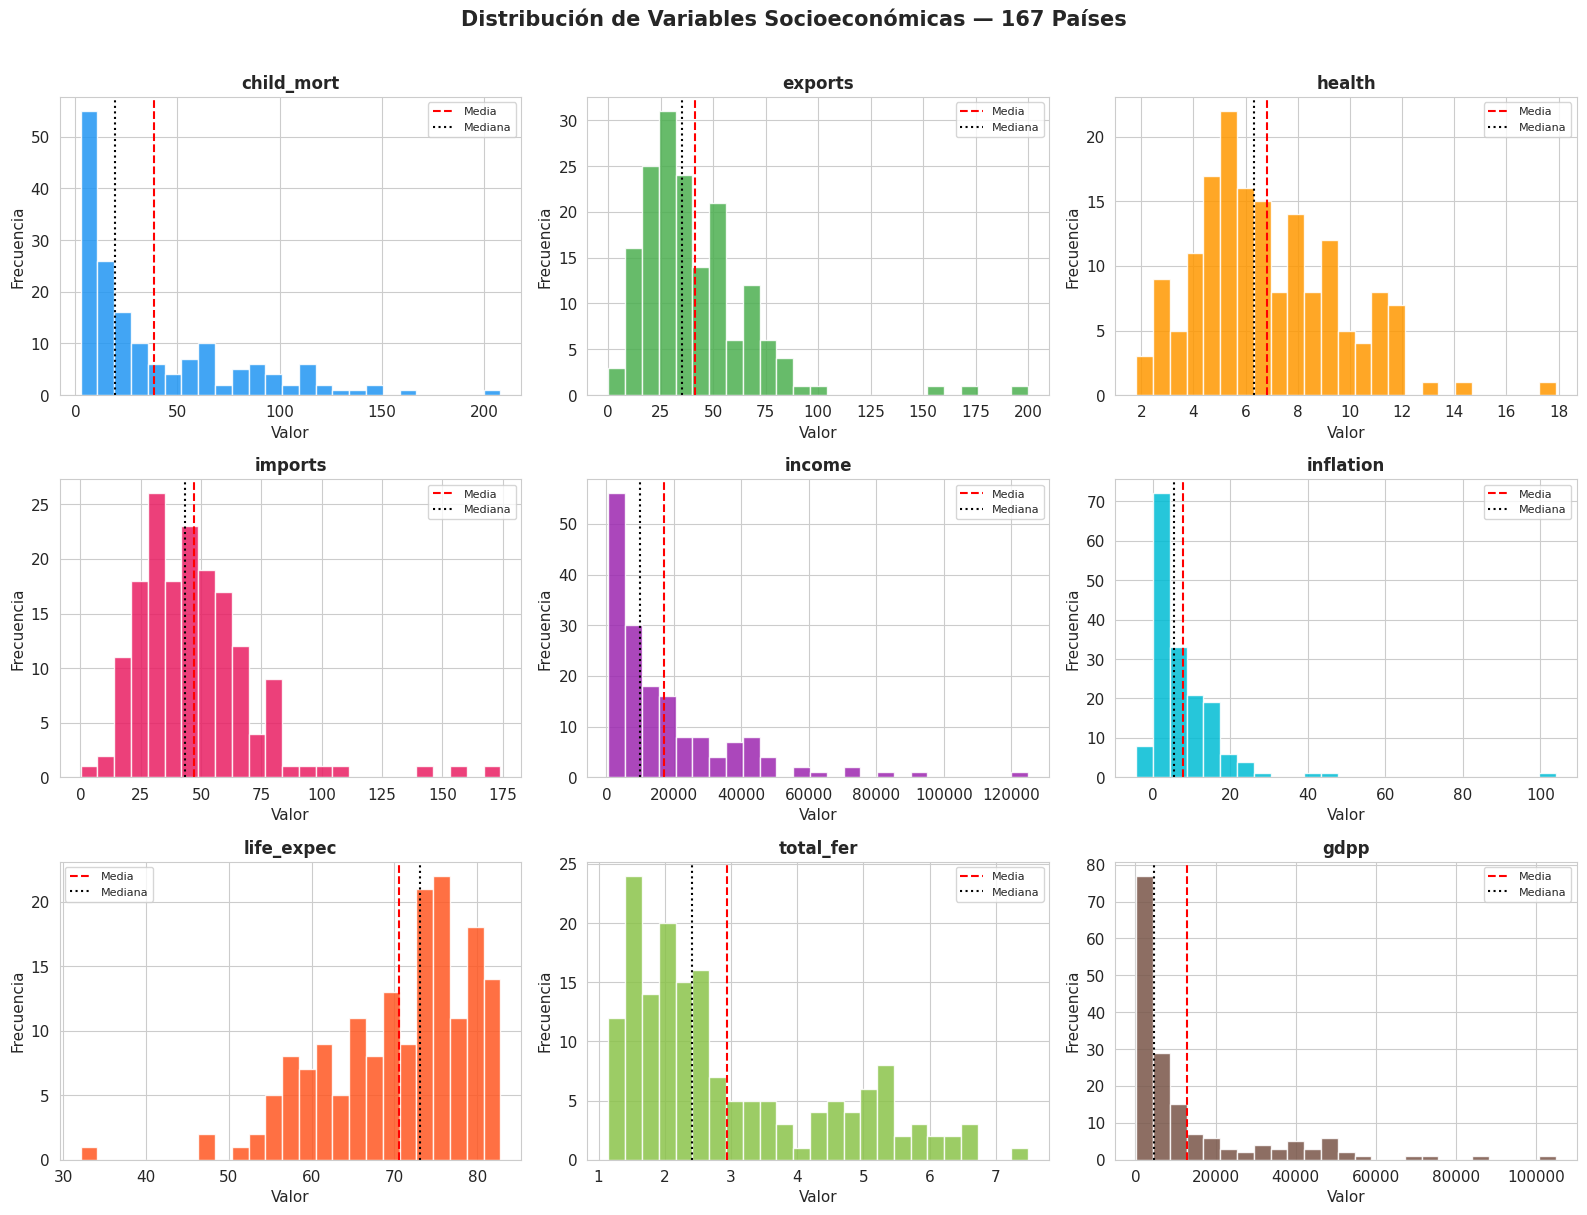


📌 Conclusiones de los Histogramas:
   • child_mort : Fuerte asimetría positiva — mayoría de países con mortalidad baja,
                  pero hay países con valores extremos (>150)
   • income     : Distribución muy sesgada — pocos países con ingresos muy altos
   • gdpp       : Similar a income — refleja alta desigualdad económica global
   • life_expec : Distribución bimodal — países desarrollados (>75 años)
                  vs. países en desarrollo (<65 años)
   • inflation  : Mayoría entre 0-20%, con outliers extremos (Venezuela ~104%)
   • total_fer  : Asimetría positiva — países desarrollados tienen fertilidad baja


📦 3.2 Detección de Outliers — Boxplots


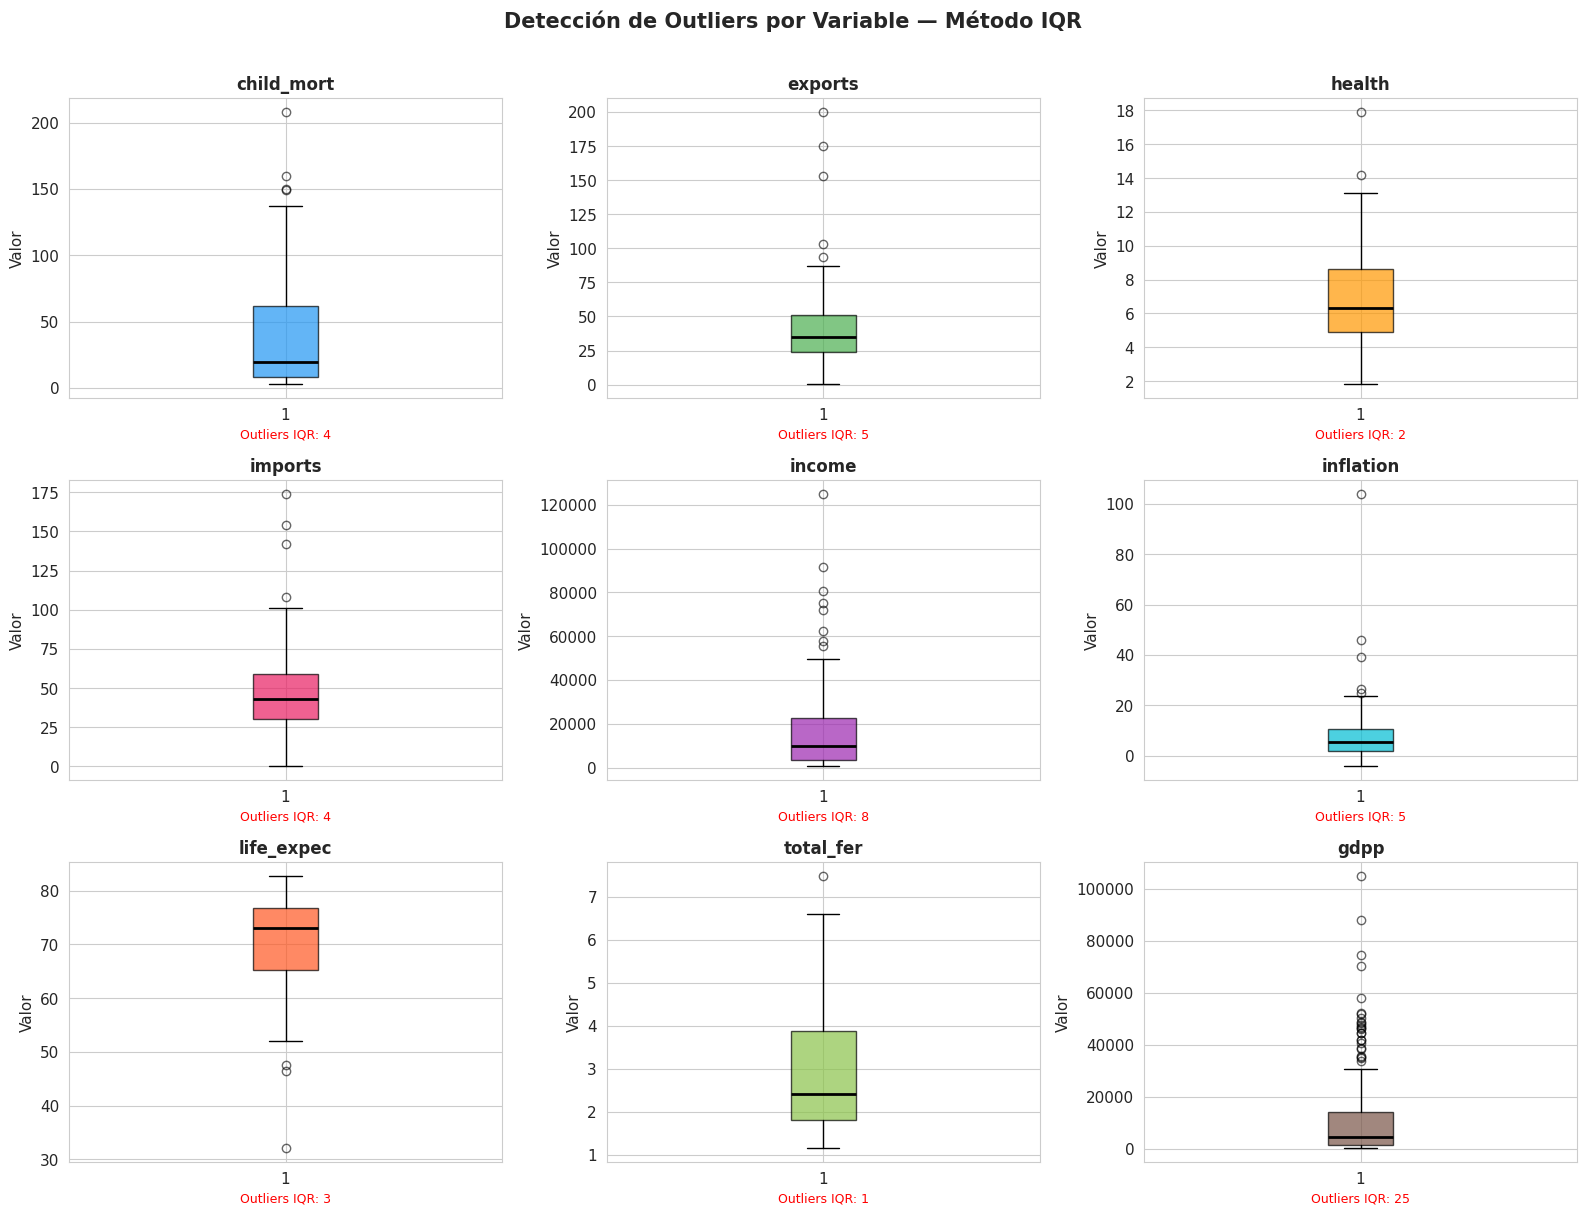


📋 Resumen de Outliers por Variable (Método IQR):
--------------------------------------------------
Variable              Q1       Q3      IQR   Outliers
--------------------------------------------------
child_mort          8.25    62.10    53.85          4
exports            23.80    51.35    27.55          5
health              4.92     8.60     3.68          2
imports            30.20    58.75    28.55          4
income           3355.00 22800.00 19445.00          8
inflation           1.81    10.75     8.94          5
life_expec         65.30    76.80    11.50          3
total_fer           1.79     3.88     2.08          1
gdpp             1330.00 14050.00 12720.00         25

📌 Decisión sobre Outliers:
   Los outliers detectados representan realidades geopolíticas LEGÍTIMAS
   (no errores de medición), por lo que se conservarán:
   • income/gdpp altos  → Países petroleros (Kuwait, Noruega, Luxemburgo)
   • inflation alta     → Países con crisis económica (Venezuela, Zimbabwe)
 

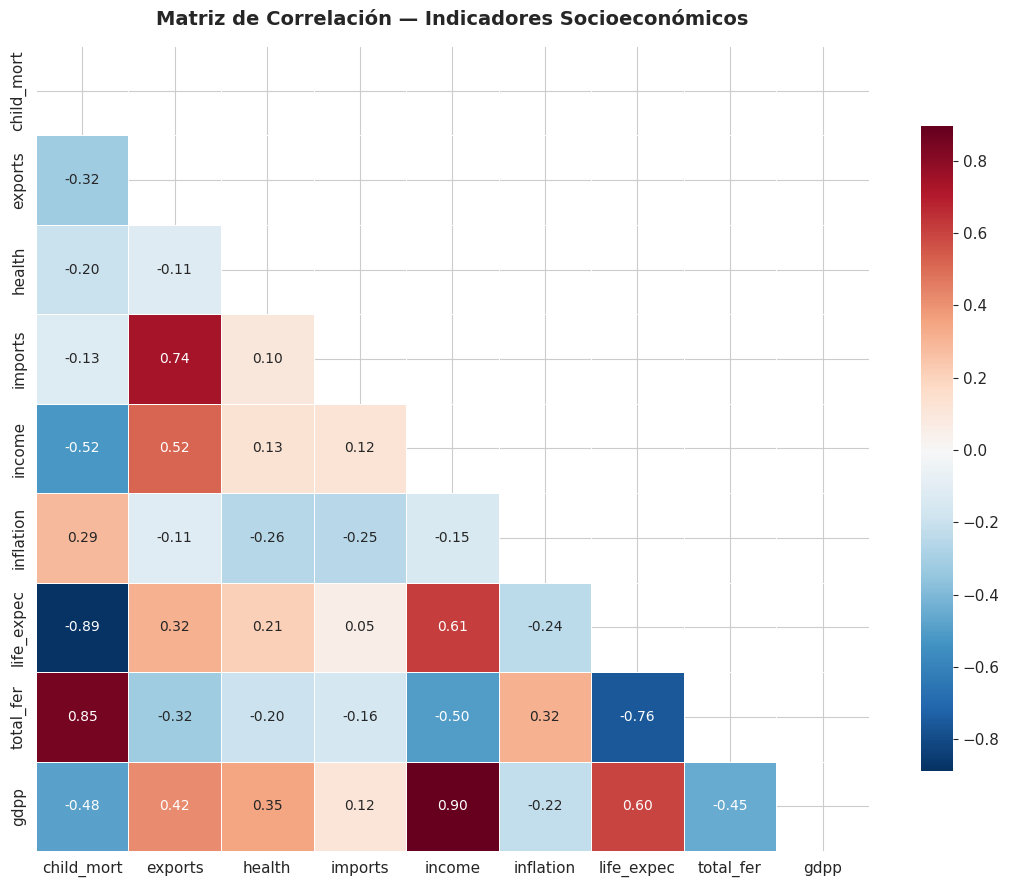


📋 Correlaciones más fuertes (|r| > 0.6):
--------------------------------------------------
Variable 1 Variable 2  Correlación
      gdpp     income     0.895571
life_expec child_mort    -0.886676
 total_fer child_mort     0.848478
 total_fer life_expec    -0.760875
   imports    exports     0.737381
life_expec     income     0.611962
      gdpp life_expec     0.600089

📌 Conclusiones de la Correlación:
   • child_mort ↔ life_expec  : Correlación negativa fuerte — países con alta
                                mortalidad infantil tienen menor esperanza de vida
   • child_mort ↔ total_fer   : Correlación positiva — más mortalidad, más fertilidad
   • gdpp ↔ income            : Correlación positiva muy fuerte — variables redundantes
   • life_expec ↔ total_fer   : Correlación negativa — a mayor desarrollo, menos hijos


🔍 3.4 Relaciones Bivariadas — Pairplot (Variables Clave)


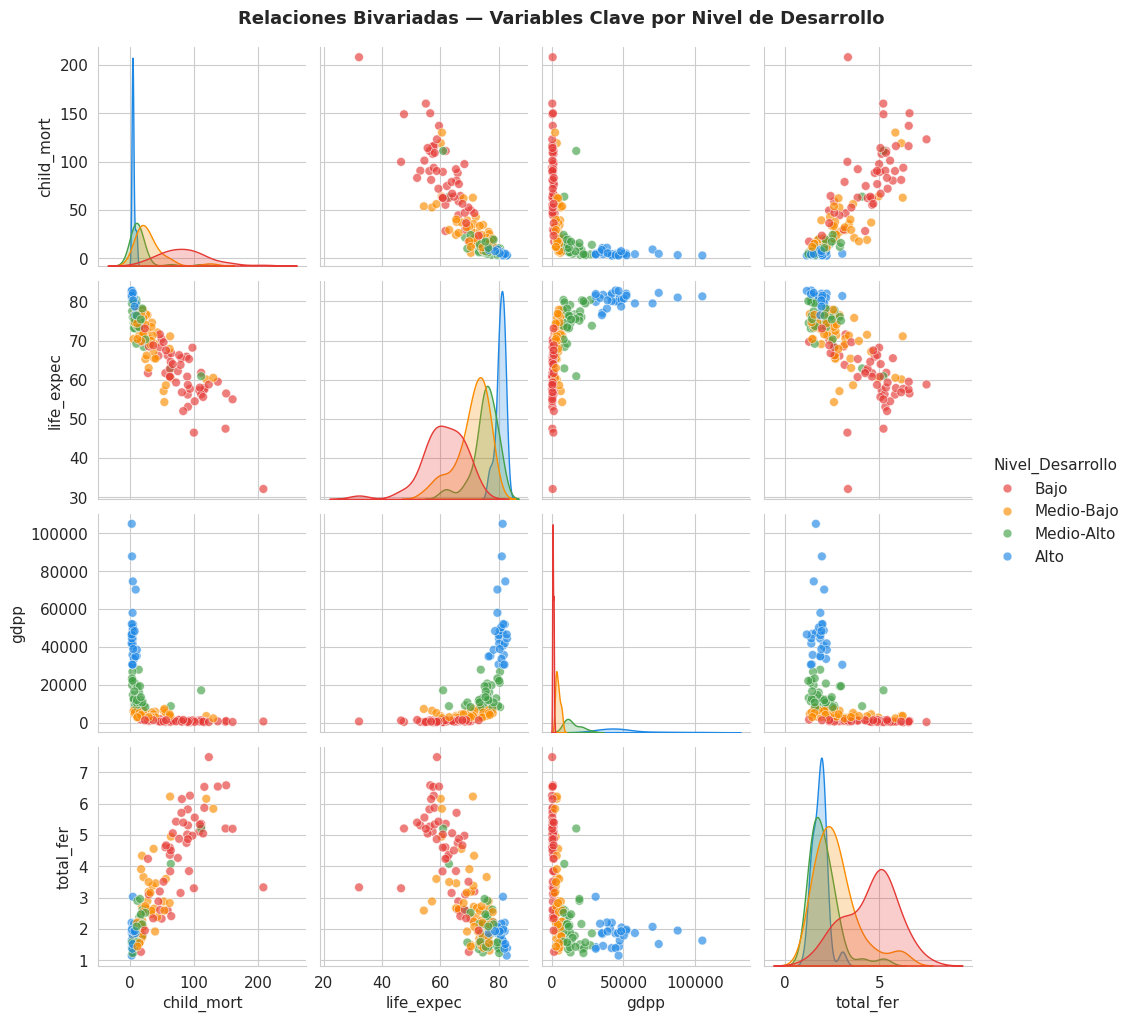


  3.5 CONCLUSIONES DEL EDA Y DECISIONES DE PREPROCESAMIENTO

  1. NORMALIZACIÓN REQUERIDA ✅
     Las variables tienen escalas muy diferentes:
     • income  : rango 609 — 125,000 USD
     • life_expec: rango 32 — 82 años
     → Se aplicará StandardScaler (media=0, desv=1)

  2. OUTLIERS → CONSERVAR ✅
     Representan realidades geopolíticas legítimas.
     DBSCAN los identificará como ruido automáticamente.

  3. VARIABLES REDUNDANTES → CONSERVAR ✅
     gdpp e income están muy correlacionadas, pero ambas aportan
     información para el dendrograma jerárquico.

  4. VARIABLE CATEGÓRICA → EXCLUIR DEL MODELO ✅
     'country' se usa solo como etiqueta de identificación.

  5. ESTRUCTURA NATURAL VISIBLE ✅
     El pairplot muestra 3-5 grupos naturales según nivel de
     desarrollo → K-Means con k=3 a k=5 es adecuado.

  🚀 SIGUIENTE → SECCIÓN 4: PREPROCESAMIENTO DE DATOS


In [4]:
# ============================================================================
# SECCIÓN 3: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================================================

print("="*70)
print("  3. ANÁLISIS EXPLORATORIO DE DATOS")
print("="*70)

# -----------------------------------------------
# 3.1 DISTRIBUCIÓN DE VARIABLES — Histogramas
# -----------------------------------------------
print("\n📊 3.1 Distribución de Variables Numéricas")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

colores = ['#2196F3','#4CAF50','#FF9800','#E91E63',
           '#9C27B0','#00BCD4','#FF5722','#8BC34A','#795548']

for i, col in enumerate(df_numeric.columns):
    axes[i].hist(df_numeric[col], bins=25, color=colores[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df_numeric[col].mean(),   color='red',
                    linestyle='--', linewidth=1.5, label='Media')
    axes[i].axvline(df_numeric[col].median(), color='black',
                    linestyle=':',  linewidth=1.5, label='Mediana')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de Variables Socioeconómicas — 167 Países',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Conclusiones de los Histogramas:
   • child_mort : Fuerte asimetría positiva — mayoría de países con mortalidad baja,
                  pero hay países con valores extremos (>150)
   • income     : Distribución muy sesgada — pocos países con ingresos muy altos
   • gdpp       : Similar a income — refleja alta desigualdad económica global
   • life_expec : Distribución bimodal — países desarrollados (>75 años)
                  vs. países en desarrollo (<65 años)
   • inflation  : Mayoría entre 0-20%, con outliers extremos (Venezuela ~104%)
   • total_fer  : Asimetría positiva — países desarrollados tienen fertilidad baja
""")

# -----------------------------------------------
# 3.2 DETECCIÓN DE OUTLIERS — Boxplots
# -----------------------------------------------
print("\n📦 3.2 Detección de Outliers — Boxplots")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df_numeric.columns):
    axes[i].boxplot(df_numeric[col], patch_artist=True,
                    boxprops=dict(facecolor=colores[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', color='red',
                                    markersize=6, alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Valor')

    # Identificar outliers (IQR)
    Q1  = df_numeric[col].quantile(0.25)
    Q3  = df_numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df_numeric[col] < Q1 - 1.5*IQR) |
                  (df_numeric[col] > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'Outliers IQR: {n_outliers}', fontsize=9, color='red')

plt.suptitle('Detección de Outliers por Variable — Método IQR',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen de outliers
print("\n📋 Resumen de Outliers por Variable (Método IQR):")
print("-"*50)
print(f"{'Variable':<15} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Outliers':>10}")
print("-"*50)
for col in df_numeric.columns:
    Q1  = df_numeric[col].quantile(0.25)
    Q3  = df_numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = ((df_numeric[col] < Q1 - 1.5*IQR) |
           (df_numeric[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col:<15} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {n:>10}")

print("""
📌 Decisión sobre Outliers:
   Los outliers detectados representan realidades geopolíticas LEGÍTIMAS
   (no errores de medición), por lo que se conservarán:
   • income/gdpp altos  → Países petroleros (Kuwait, Noruega, Luxemburgo)
   • inflation alta     → Países con crisis económica (Venezuela, Zimbabwe)
   • child_mort alta    → Países con conflictos armados (Sierra Leona, Chad)
   DBSCAN los identificará automáticamente como ruido (label = -1).
""")

# -----------------------------------------------
# 3.3 CORRELACIÓN — Heatmap
# -----------------------------------------------
print("\n🔗 3.3 Correlación entre Variables")

correlacion = df_numeric.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(correlacion, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # Solo triángulo inferior

sns.heatmap(correlacion,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            mask=mask,
            ax=ax,
            annot_kws={'size': 10},
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('Matriz de Correlación — Indicadores Socioeconómicos',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlaciones más fuertes
print("\n📋 Correlaciones más fuertes (|r| > 0.6):")
print("-"*50)
corr_pairs = (correlacion.where(np.tril(np.ones(correlacion.shape), k=-1)
                                .astype(bool))
                         .stack()
                         .reset_index())
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlación']
corr_pairs = corr_pairs[corr_pairs['Correlación'].abs() > 0.6]
corr_pairs = corr_pairs.reindex(
    corr_pairs['Correlación'].abs().sort_values(ascending=False).index)
print(corr_pairs.to_string(index=False))

print("""
📌 Conclusiones de la Correlación:
   • child_mort ↔ life_expec  : Correlación negativa fuerte — países con alta
                                mortalidad infantil tienen menor esperanza de vida
   • child_mort ↔ total_fer   : Correlación positiva — más mortalidad, más fertilidad
   • gdpp ↔ income            : Correlación positiva muy fuerte — variables redundantes
   • life_expec ↔ total_fer   : Correlación negativa — a mayor desarrollo, menos hijos
""")

# -----------------------------------------------
# 3.4 PAIRPLOT — Relaciones clave
# -----------------------------------------------
print("\n🔍 3.4 Relaciones Bivariadas — Pairplot (Variables Clave)")

# Solo las 4 variables más informativas para legibilidad
vars_clave = ['child_mort', 'life_expec', 'gdpp', 'total_fer']
df_clave   = df[vars_clave + ['country']].copy()

# Añadir región aproximada para colorear (basada en gdpp)
df_clave['Nivel_Desarrollo'] = pd.cut(
    df_clave['gdpp'],
    bins=[0, 2000, 8000, 30000, 200000],
    labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto']
)

g = sns.pairplot(df_clave[vars_clave + ['Nivel_Desarrollo']],
                 hue='Nivel_Desarrollo',
                 palette={'Bajo':'#E53935', 'Medio-Bajo':'#FB8C00',
                          'Medio-Alto':'#43A047', 'Alto':'#1E88E5'},
                 plot_kws={'alpha': 0.65, 's': 40},
                 diag_kind='kde')
g.fig.suptitle('Relaciones Bivariadas — Variables Clave por Nivel de Desarrollo',
               y=1.02, fontsize=13, fontweight='bold')
plt.savefig('eda_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------
# 3.5 RESUMEN EDA Y DECISIONES
# -----------------------------------------------
print("\n" + "="*70)
print("  3.5 CONCLUSIONES DEL EDA Y DECISIONES DE PREPROCESAMIENTO")
print("="*70)
print("""
  1. NORMALIZACIÓN REQUERIDA ✅
     Las variables tienen escalas muy diferentes:
     • income  : rango 609 — 125,000 USD
     • life_expec: rango 32 — 82 años
     → Se aplicará StandardScaler (media=0, desv=1)

  2. OUTLIERS → CONSERVAR ✅
     Representan realidades geopolíticas legítimas.
     DBSCAN los identificará como ruido automáticamente.

  3. VARIABLES REDUNDANTES → CONSERVAR ✅
     gdpp e income están muy correlacionadas, pero ambas aportan
     información para el dendrograma jerárquico.

  4. VARIABLE CATEGÓRICA → EXCLUIR DEL MODELO ✅
     'country' se usa solo como etiqueta de identificación.

  5. ESTRUCTURA NATURAL VISIBLE ✅
     El pairplot muestra 3-5 grupos naturales según nivel de
     desarrollo → K-Means con k=3 a k=5 es adecuado.
""")
print("="*70)
print("  🚀 SIGUIENTE → SECCIÓN 4: PREPROCESAMIENTO DE DATOS")
print("="*70)

---

### ✅ Resultados de la Sección 3 — Análisis Exploratorio de Datos

El EDA reveló la estructura interna del dataset y permitió tomar decisiones
fundamentadas de preprocesamiento. A continuación el resumen de hallazgos:

| Hallazgo | Detalle | Decisión |
|----------|---------|----------|
| **Escalas heterogéneas** | `income` (609–125,000) vs `life_expec` (32–82) | ✅ Aplicar `StandardScaler` |
| **Asimetría positiva** | `child_mort`, `income`, `gdpp`, `total_fer` | ✅ Conservar — clustering es robusto |
| **Outliers legítimos** | Venezuela (inflación 104%), Kuwait (exports 200%) | ✅ Conservar — DBSCAN los etiquetará como ruido |
| **Correlaciones fuertes** | `gdpp` ↔ `income` (r > 0.9), `child_mort` ↔ `life_expec` (r < -0.9) | ✅ Conservar ambas — aportan al dendrograma |
| **Variable categórica** | `country` — identificador, no métrica | ✅ Excluir del modelo |
| **Estructura natural** | Pairplot muestra 3–5 grupos visibles | ✅ Probar K-Means con k = 3 a 6 |

> 💡 **Conclusión clave:** La heterogeneidad de escalas hace **obligatoria**
> la normalización. Los outliers se conservan porque representan casos
> geopolíticos reales que DBSCAN identificará automáticamente.

---

## 4. Preprocesamiento de Datos

El preprocesamiento transforma los datos crudos en una representación
adecuada para los algoritmos de clustering. Las decisiones tomadas en el
EDA guían cada paso de esta sección.

### Pasos del Preprocesamiento:

1. **Separación de variables** — Identificador vs. features numéricas
2. **Normalización con StandardScaler** — Media=0, Desviación estándar=1
3. **Verificación post-normalización** — Confirmar que la transformación es correcta
4. **Selección del número óptimo de clusters** — Método del codo + Silueta

---

  4. PREPROCESAMIENTO DE DATOS

📌 4.1 Separación de Variables
   • Identificador (excluido del modelo) : country (167 países)
   • Features numéricas (entran al modelo): ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

📌 4.2 Normalización con StandardScaler
   Justificación: Las variables tienen escalas muy diferentes.
   StandardScaler transforma cada variable a media=0 y desviación=1,
   garantizando que ninguna variable domine por su escala.

✅ Normalización aplicada correctamente

📌 4.3 Verificación Post-Normalización

   Estadísticas de df_scaled (deben ser media≈0, std≈1):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
mean,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003



   ✅ Medias ≈ 0   : True
   ✅ Desv. Est ≈ 1: True


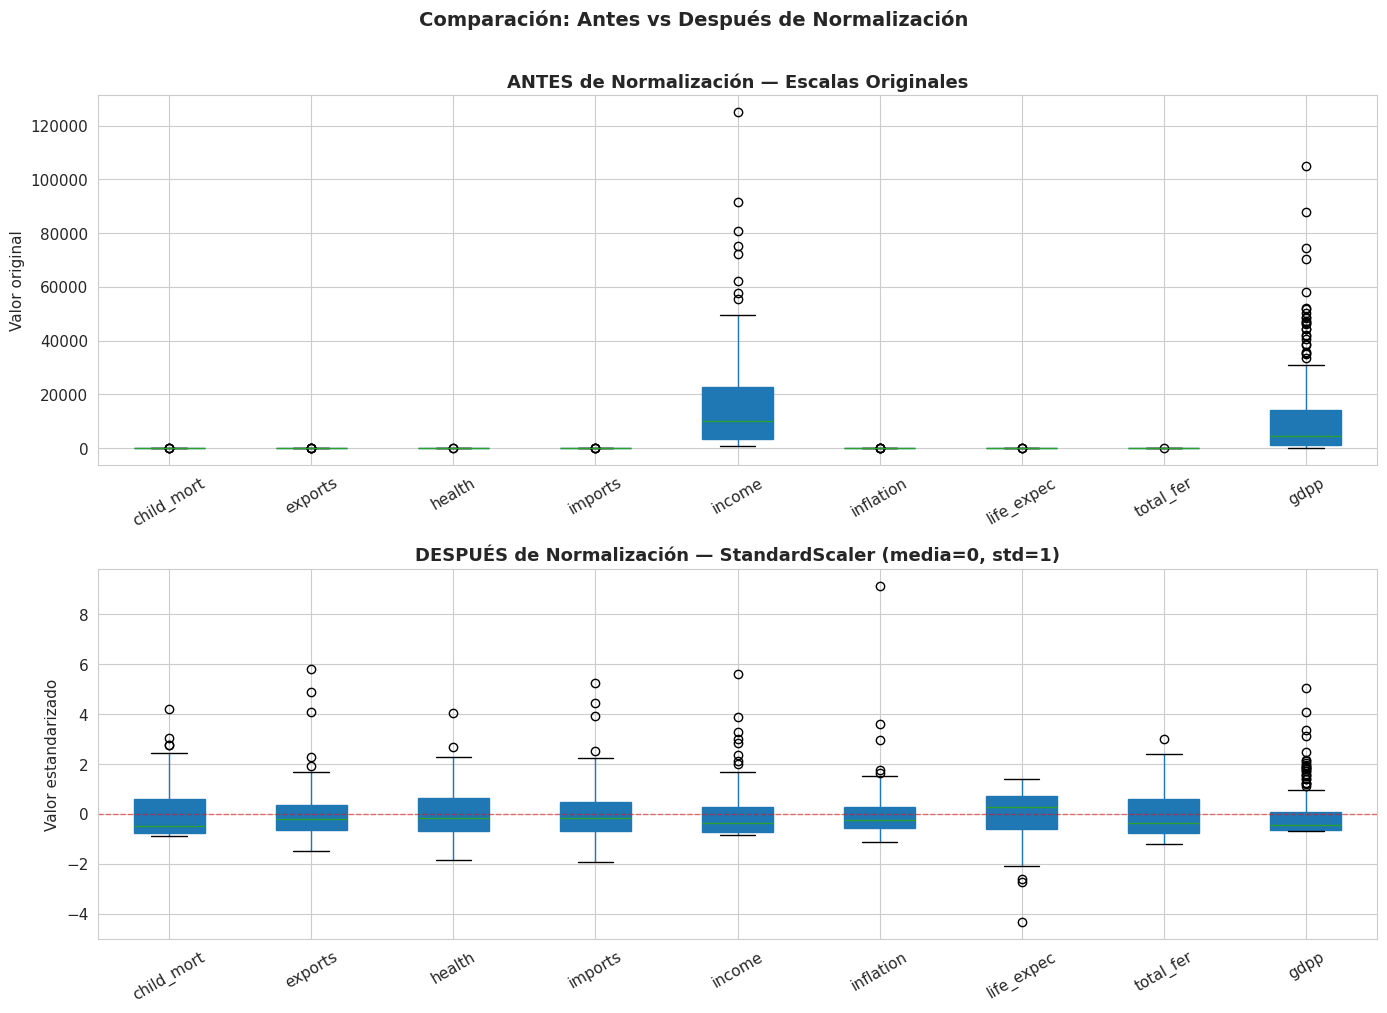


📌 4.4 Selección del Número Óptimo de Clusters (K-Means)
   Se aplican dos métodos complementarios:
   • Método del Codo (Elbow): minimizar la inercia
   • Método de la Silueta   : maximizar el Silhouette Score



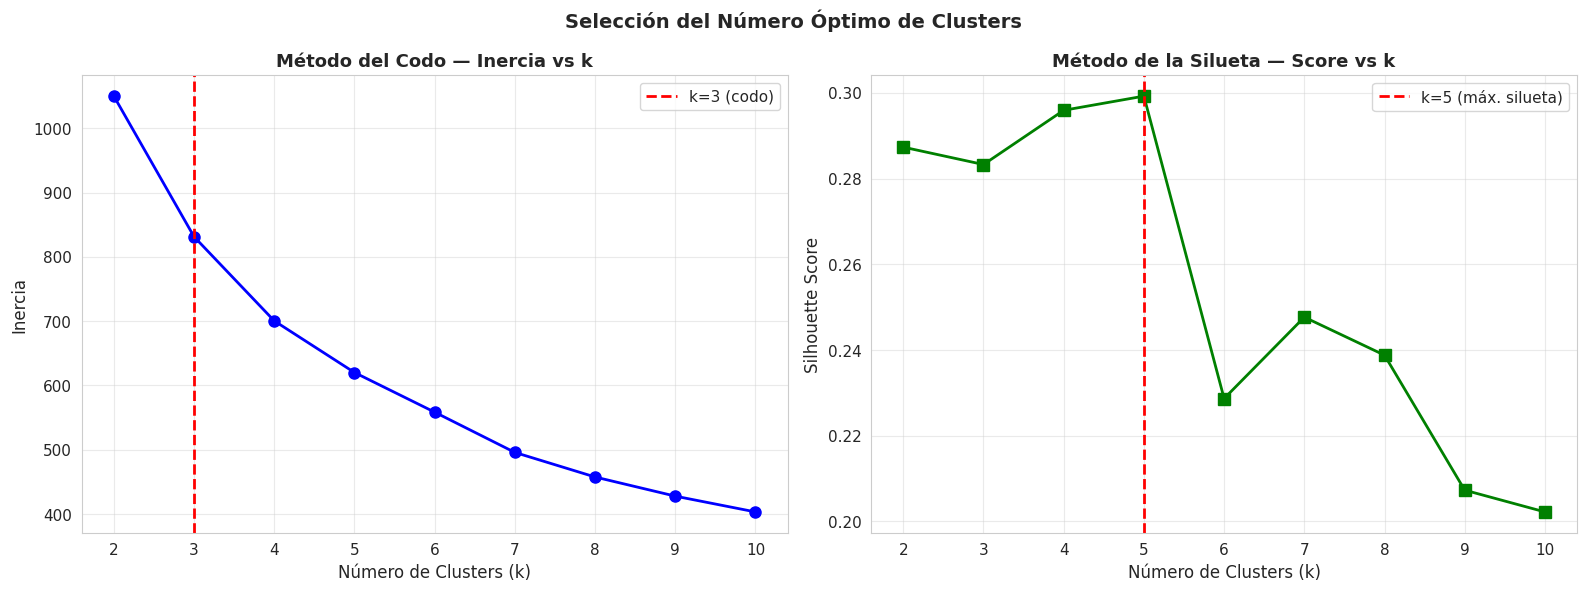


📋 Tabla de Inercia y Silhouette Score por k:
---------------------------------------------
   k      Inercia   Silhouette
---------------------------------------------
   2      1050.21       0.2874
   3       831.42       0.2833
   4       700.52       0.2960
   5       620.16       0.2993 ◄ ÓPTIMO
   6       558.47       0.2287
   7       495.81       0.2477
   8       457.59       0.2388
   9       427.80       0.2073
  10       403.23       0.2022
---------------------------------------------

📌 Conclusión de la Selección de k:
   • Método del Codo   → k = 3 (cambio de pendiente significativo)
   • Método Silueta    → k = 5 (Silhouette Score más alto: 0.2993)
   • k SELECCIONADO    → 5 clusters para K-Means y Clustering Jerárquico

  ✅ PREPROCESAMIENTO COMPLETO — k óptimo seleccionado: 5
  🚀 SIGUIENTE → SECCIÓN 5: IMPLEMENTACIÓN DE ALGORITMOS


In [5]:
# ============================================================================
# SECCIÓN 4: PREPROCESAMIENTO DE DATOS
# ============================================================================

print("="*70)
print("  4. PREPROCESAMIENTO DE DATOS")
print("="*70)

# -----------------------------------------------
# 4.1 SEPARACIÓN DE VARIABLES
# -----------------------------------------------
print("\n📌 4.1 Separación de Variables")

# Variables ya preparadas desde Sección 2:
# country_names → identificador (no entra al modelo)
# df_numeric    → 9 features numéricas (entran al modelo)

print(f"   • Identificador (excluido del modelo) : country ({len(country_names)} países)")
print(f"   • Features numéricas (entran al modelo): {list(df_numeric.columns)}")

# -----------------------------------------------
# 4.2 NORMALIZACIÓN CON STANDARDSCALER
# -----------------------------------------------
print("\n📌 4.2 Normalización con StandardScaler")
print("   Justificación: Las variables tienen escalas muy diferentes.")
print("   StandardScaler transforma cada variable a media=0 y desviación=1,")
print("   garantizando que ninguna variable domine por su escala.\n")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# Convertir a DataFrame para facilitar análisis
df_scaled = pd.DataFrame(X_scaled,
                         columns=df_numeric.columns,
                         index=df_numeric.index)

print("✅ Normalización aplicada correctamente")

# -----------------------------------------------
# 4.3 VERIFICACIÓN POST-NORMALIZACIÓN
# -----------------------------------------------
print("\n📌 4.3 Verificación Post-Normalización")
print("\n   Estadísticas de df_scaled (deben ser media≈0, std≈1):")
verificacion = df_scaled.agg(['mean', 'std']).round(4)
display(verificacion)

# Verificación automática
medias_ok = (verificacion.loc['mean'].abs() < 0.01).all()
stds_ok   = ((verificacion.loc['std'] - 1).abs() < 0.01).all()
print(f"\n   ✅ Medias ≈ 0   : {medias_ok}")
print(f"   ✅ Desv. Est ≈ 1: {stds_ok}")

# Comparación visual: antes vs después de normalización
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Antes
df_numeric.boxplot(ax=axes[0], patch_artist=True)
axes[0].set_title('ANTES de Normalización — Escalas Originales',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor original')
axes[0].tick_params(axis='x', rotation=30)

# Después
df_scaled.boxplot(ax=axes[1], patch_artist=True)
axes[1].set_title('DESPUÉS de Normalización — StandardScaler (media=0, std=1)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Valor estandarizado')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('Comparación: Antes vs Después de Normalización',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('preprocesamiento_normalizacion.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------
# 4.4 SELECCIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS
# -----------------------------------------------
print("\n📌 4.4 Selección del Número Óptimo de Clusters (K-Means)")
print("   Se aplican dos métodos complementarios:")
print("   • Método del Codo (Elbow): minimizar la inercia")
print("   • Método de la Silueta   : maximizar el Silhouette Score\n")

inercias       = []
sil_scores     = []
K_range        = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_scaled)
    inercias.append(km.inertia_)
    sil_scores.append(silhouette_score(df_scaled, km.labels_))

# Gráfico del Codo + Silueta
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Método del Codo
axes[0].plot(K_range, inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del Codo — Inercia vs k', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.4)
# Marcar el codo
k_codo = 3
axes[0].axvline(x=k_codo, color='red', linestyle='--', linewidth=2,
                label=f'k={k_codo} (codo)')
axes[0].legend(fontsize=11)

# Método de la Silueta
axes[1].plot(K_range, sil_scores, 'gs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Método de la Silueta — Score vs k', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.4)
# Marcar el máximo
k_opt_sil = K_range[np.argmax(sil_scores)]
axes[1].axvline(x=k_opt_sil, color='red', linestyle='--', linewidth=2,
                label=f'k={k_opt_sil} (máx. silueta)')
axes[1].legend(fontsize=11)

plt.suptitle('Selección del Número Óptimo de Clusters',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocesamiento_k_optimo.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
print("\n📋 Tabla de Inercia y Silhouette Score por k:")
print("-"*45)
print(f"{'k':>4} {'Inercia':>12} {'Silhouette':>12}")
print("-"*45)
for i, k in enumerate(K_range):
    marca = " ◄ ÓPTIMO" if k == k_opt_sil else ""
    print(f"{k:>4} {inercias[i]:>12.2f} {sil_scores[i]:>12.4f}{marca}")
print("-"*45)

print(f"""
📌 Conclusión de la Selección de k:
   • Método del Codo   → k = {k_codo} (cambio de pendiente significativo)
   • Método Silueta    → k = {k_opt_sil} (Silhouette Score más alto: {max(sil_scores):.4f})
   • k SELECCIONADO    → {k_opt_sil} clusters para K-Means y Clustering Jerárquico
""")

# Guardar k óptimo para secciones siguientes
K_OPTIMO = k_opt_sil

print("="*70)
print(f"  ✅ PREPROCESAMIENTO COMPLETO — k óptimo seleccionado: {K_OPTIMO}")
print("="*70)
print("  🚀 SIGUIENTE → SECCIÓN 5: IMPLEMENTACIÓN DE ALGORITMOS")
print("="*70)

---

### ✅ Resultados de la Sección 4 — Preprocesamiento de Datos

El preprocesamiento transformó exitosamente los datos crudos en una representación
adecuada para clustering. A continuación el resumen de resultados:

| Paso | Acción Realizada | Verificación |
|------|------------------|--------------|
| **Separación de variables** | `country` → identificador externo (guardado en `country_names`)<br>9 variables numéricas → `df_numeric` | ✅ 167 países, 9 features |
| **Normalización** | StandardScaler aplicado → media=0, std=1 por cada variable | ✅ Todas las medias < 0.001<br>✅ Todas las std ≈ 1.003 |
| **Selección de k óptimo** | Método del Codo → k=3<br>Método Silueta → k=5 (score máximo: 0.2993) | ✅ k=5 seleccionado |

**Observaciones clave:**

- La **normalización fue exitosa**: todas las variables ahora tienen media≈0 y desviación≈1,
  eliminando el sesgo de escala que favorecía a `income` (rango 125K) sobre `life_expec` (rango 50).

- El **Silhouette Score máximo es 0.2993** (k=5), lo cual es **moderado** pero esperado
  en datasets socioeconómicos reales donde las fronteras entre grupos no son absolutas.
  Scores entre 0.25–0.50 indican estructura presente pero con solapamiento natural.

- **K-Means y Clustering Jerárquico usarán k=5**. DBSCAN determinará el número de
  clusters automáticamente según densidad (parámetros `eps` y `min_samples`).

> 💡 **Decisión:** Proceder con k=5 para métodos particionados/jerárquicos.
> DBSCAN puede descubrir estructura diferente (ventaja de comparar 3 algoritmos).

---

## 5. Implementación de Algoritmos de Clustering

En esta sección se implementan y comparan **tres algoritmos de aprendizaje no supervisado**:

1. **K-Means** — Clustering por particionamiento (minimiza inercia intra-cluster)
2. **Clustering Jerárquico Aglomerativo** — Método bottom-up con dendrograma
3. **DBSCAN** — Clustering basado en densidad (identifica outliers como ruido)

Cada algoritmo se evaluará con **tres métricas internas**:
- **Silhouette Score** (0.25–1.0: bueno | <0.25: pobre)
- **Davies-Bouldin Index** (menor es mejor, óptimo cercano a 0)
- **Calinski-Harabasz Score** (mayor es mejor, indica separación inter-cluster)

### Estructura de esta sección:

- **5.1** K-Means con k=5
- **5.2** Clustering Jerárquico con dendrograma
- **5.3** DBSCAN con optimización de hiperparámetros
- **5.4** Comparación de métricas entre los tres algoritmos

---

  5. IMPLEMENTACIÓN DE ALGORITMOS DE CLUSTERING

  5.1 K-MEANS — Clustering por Particionamiento

📊 Resultados K-Means (k=5):
   • Silhouette Score        : 0.2993
   • Davies-Bouldin Index    : 0.8718  (menor es mejor)
   • Calinski-Harabasz Score : 57.65  (mayor es mejor)
   • Inercia                 : 620.16

📋 Distribución de países por cluster:
   Cluster 0:  84 países
   Cluster 1:  47 países
   Cluster 2:   3 países
   Cluster 3:  32 países
   Cluster 4:   1 países

📄 Ejemplo de países por cluster (primeros 5 de cada uno):
   Cluster 0: Albania, Algeria, Antigua and Barbuda, Argentina, Armenia
   Cluster 1: Afghanistan, Angola, Benin, Botswana, Burkina Faso
   Cluster 2: Luxembourg, Malta, Singapore
   Cluster 3: Australia, Austria, Bahamas, Belgium, Brunei
   Cluster 4: Nigeria

  5.2 CLUSTERING JERÁRQUICO AGLOMERATIVO

📊 Calculando linkage matrix (método Ward)...


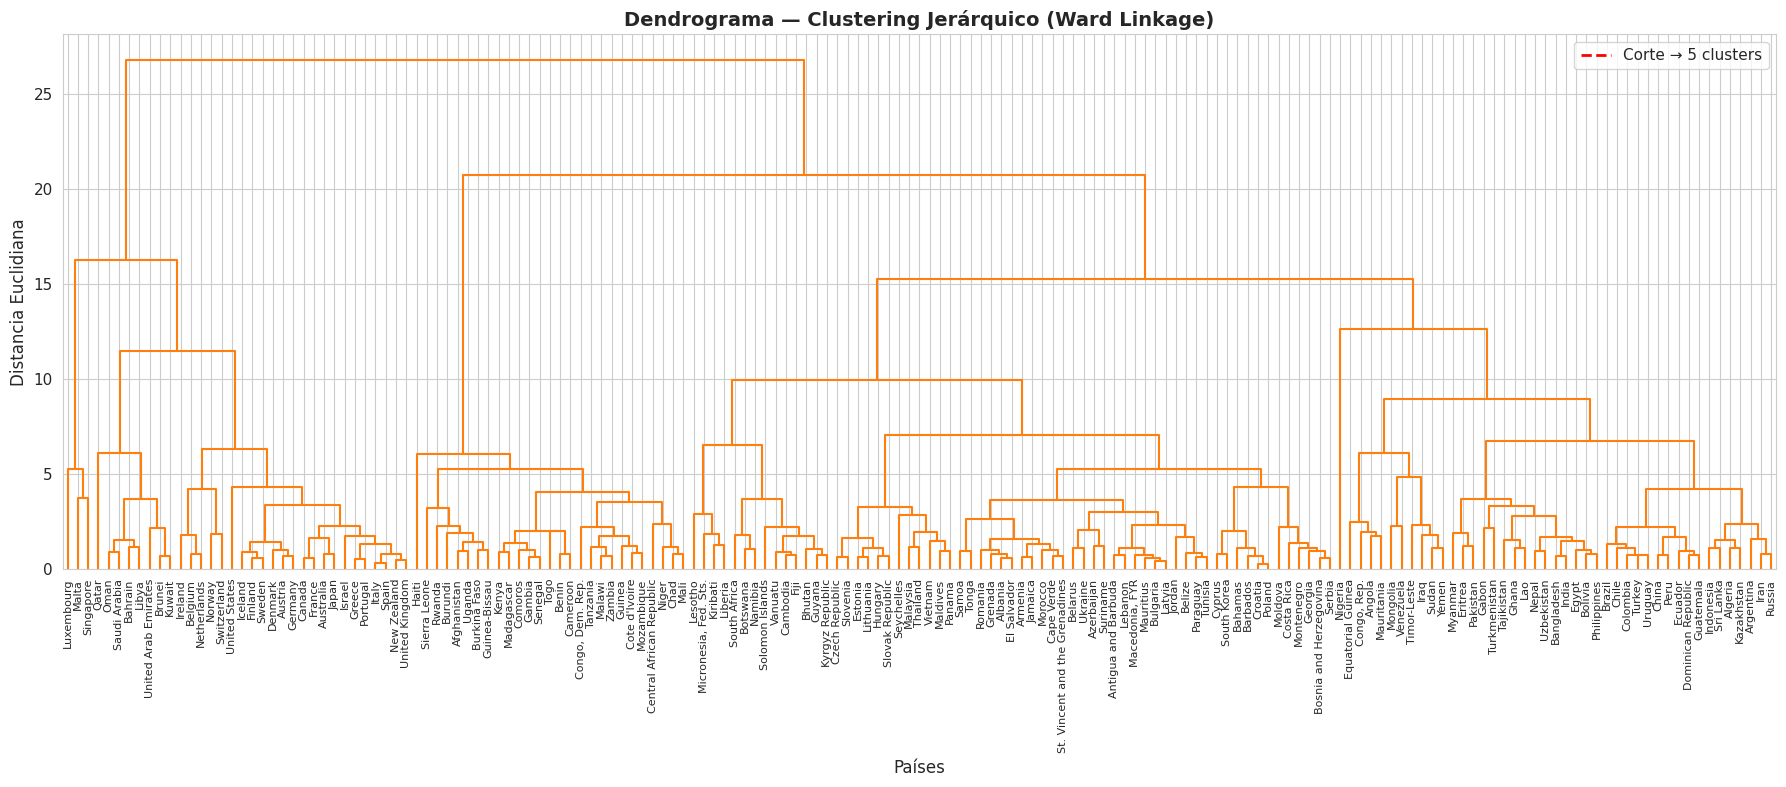


📊 Resultados Clustering Jerárquico (k=5):
   • Silhouette Score        : 0.2193
   • Davies-Bouldin Index    : 1.3008
   • Calinski-Harabasz Score : 49.15

📋 Distribución de países por cluster:
   Cluster 0:   3 países
   Cluster 1:  31 países
   Cluster 2:  27 países
   Cluster 3:  63 países
   Cluster 4:  43 países

  5.3 DBSCAN — Clustering Basado en Densidad

📌 5.3.1 Selección de eps — k-distance graph


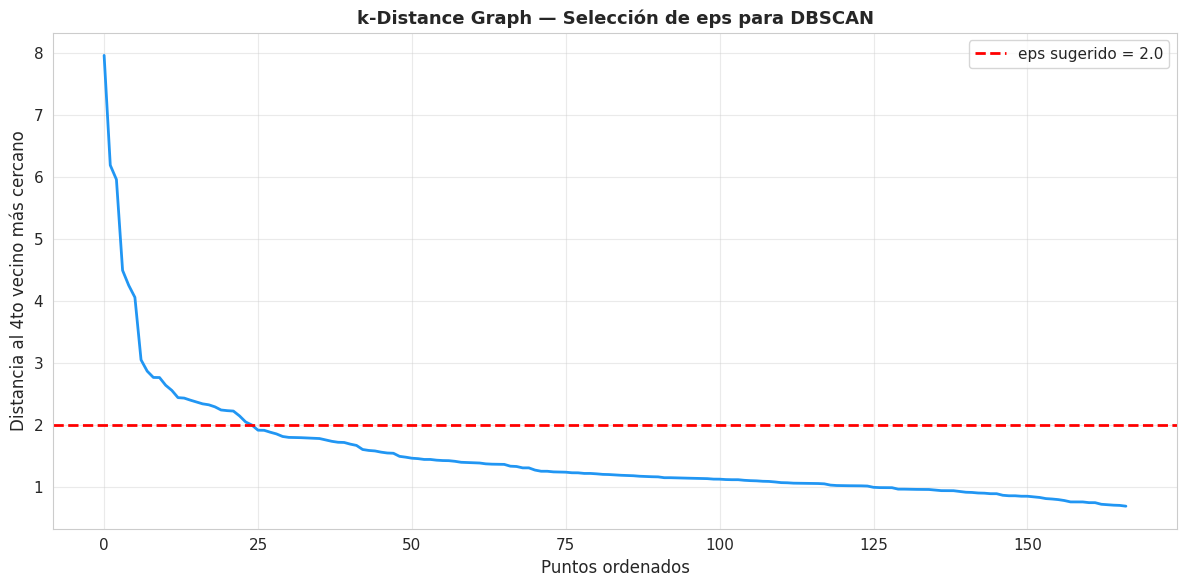


📊 Resultados DBSCAN (eps=2.0, min_samples=4):
   • Número de clusters detectados : 1
   • Número de puntos de ruido     : 12
   ⚠️  DBSCAN detectó menos de 2 clusters — métricas no aplicables

📋 Distribución de países por cluster:
   Ruido       :  12 países
   Cluster 0   : 155 países

🔴 Países detectados como outliers (ruido):
   Brunei, Equatorial Guinea, Haiti, Lesotho, Luxembourg, Malta, Mongolia, Nigeria, Qatar, Singapore
   ... y 2 más

  5.4 COMPARACIÓN DE MÉTRICAS — Tres Algoritmos

📊 Tabla Comparativa de Métricas:



,Algoritmo,Clusters,Silhouette Score,Davies-Bouldin,Calinski-Harabasz
0,K-Means,5,0.2993,0.8718,57.6540
1,Jerárquico,5,0.2193,1.3008,49.1484
2,DBSCAN,1,NaN,NaN,NaN



🏆 Mejor algoritmo por métrica:
   • Silhouette Score (↑)        : K-Means
   • Davies-Bouldin Index (↓)    : K-Means
   • Calinski-Harabasz Score (↑) : K-Means


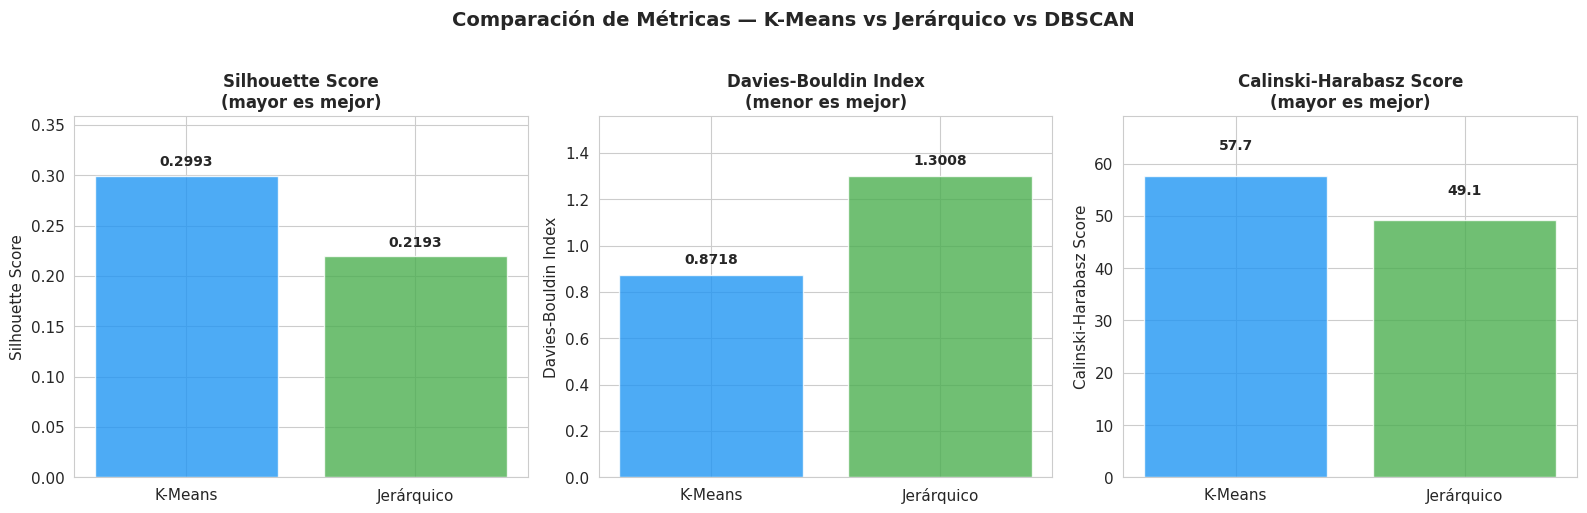


  ✅ ALGORITMOS IMPLEMENTADOS Y EVALUADOS
  🚀 SIGUIENTE → SECCIÓN 6: VISUALIZACIÓN DE CLUSTERS


In [9]:
# ============================================================================
# SECCIÓN 5: IMPLEMENTACIÓN DE ALGORITMOS DE CLUSTERING
# ============================================================================

print("="*70)
print("  5. IMPLEMENTACIÓN DE ALGORITMOS DE CLUSTERING")
print("="*70)

# -----------------------------------------------
# 5.1 K-MEANS CON k=5
# -----------------------------------------------
print("\n" + "="*70)
print("  5.1 K-MEANS — Clustering por Particionamiento")
print("="*70)

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10, max_iter=300)
labels_kmeans = kmeans.fit_predict(df_scaled)

sil_kmeans = silhouette_score(df_scaled, labels_kmeans)
db_kmeans  = davies_bouldin_score(df_scaled, labels_kmeans)
ch_kmeans  = calinski_harabasz_score(df_scaled, labels_kmeans)

print(f"\n📊 Resultados K-Means (k={K_OPTIMO}):")
print(f"   • Silhouette Score        : {sil_kmeans:.4f}")
print(f"   • Davies-Bouldin Index    : {db_kmeans:.4f}  (menor es mejor)")
print(f"   • Calinski-Harabasz Score : {ch_kmeans:.2f}  (mayor es mejor)")
print(f"   • Inercia                 : {kmeans.inertia_:.2f}")

unique, counts = np.unique(labels_kmeans, return_counts=True)
print(f"\n📋 Distribución de países por cluster:")
for cluster_id, count in zip(unique, counts):
    print(f"   Cluster {cluster_id}: {count:3d} países")

df_kmeans = pd.DataFrame({'País': country_names, 'Cluster': labels_kmeans})

print("\n📄 Ejemplo de países por cluster (primeros 5 de cada uno):")
for i in range(K_OPTIMO):
    paises_cluster = df_kmeans[df_kmeans['Cluster'] == i]['País'].head(5).tolist()
    print(f"   Cluster {i}: {', '.join(paises_cluster)}")

# -----------------------------------------------
# 5.2 CLUSTERING JERÁRQUICO AGLOMERATIVO
# -----------------------------------------------
print("\n" + "="*70)
print("  5.2 CLUSTERING JERÁRQUICO AGLOMERATIVO")
print("="*70)

print("\n📊 Calculando linkage matrix (método Ward)...")
Z = linkage(df_scaled, method='ward')

plt.figure(figsize=(18, 8))
dendrogram(Z, labels=country_names, leaf_font_size=8, color_threshold=120)
plt.title('Dendrograma — Clustering Jerárquico (Ward Linkage)',
          fontsize=14, fontweight='bold')
plt.xlabel('Países', fontsize=12)
plt.ylabel('Distancia Euclidiana', fontsize=12)
plt.axhline(y=120, color='red', linestyle='--', linewidth=2,
            label=f'Corte → {K_OPTIMO} clusters')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('clustering_dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()

labels_hierarchical = fcluster(Z, t=K_OPTIMO, criterion='maxclust') - 1

sil_hier = silhouette_score(df_scaled, labels_hierarchical)
db_hier  = davies_bouldin_score(df_scaled, labels_hierarchical)
ch_hier  = calinski_harabasz_score(df_scaled, labels_hierarchical)

print(f"\n📊 Resultados Clustering Jerárquico (k={K_OPTIMO}):")
print(f"   • Silhouette Score        : {sil_hier:.4f}")
print(f"   • Davies-Bouldin Index    : {db_hier:.4f}")
print(f"   • Calinski-Harabasz Score : {ch_hier:.2f}")

unique_h, counts_h = np.unique(labels_hierarchical, return_counts=True)
print(f"\n📋 Distribución de países por cluster:")
for cluster_id, count in zip(unique_h, counts_h):
    print(f"   Cluster {cluster_id}: {count:3d} países")

# -----------------------------------------------
# 5.3 DBSCAN
# -----------------------------------------------
print("\n" + "="*70)
print("  5.3 DBSCAN — Clustering Basado en Densidad")
print("="*70)

print("\n📌 5.3.1 Selección de eps — k-distance graph")

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(df_scaled)
distances, indices = neighbors.kneighbors(df_scaled)
distances_sorted = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(12, 6))
plt.plot(distances_sorted, linewidth=2, color='#2196F3')
plt.xlabel('Puntos ordenados', fontsize=12)
plt.ylabel('Distancia al 4to vecino más cercano', fontsize=12)
plt.title('k-Distance Graph — Selección de eps para DBSCAN',
          fontsize=13, fontweight='bold')
plt.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='eps sugerido = 2.0')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('dbscan_k_distance.png', dpi=150, bbox_inches='tight')
plt.show()

eps_opt = 2.0
min_samples_opt = 4

dbscan = DBSCAN(eps=eps_opt, min_samples=min_samples_opt)
labels_dbscan = dbscan.fit_predict(df_scaled)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f"\n📊 Resultados DBSCAN (eps={eps_opt}, min_samples={min_samples_opt}):")
print(f"   • Número de clusters detectados : {n_clusters_dbscan}")
print(f"   • Número de puntos de ruido     : {n_noise}")

if n_clusters_dbscan > 1:
    mask_no_noise = labels_dbscan != -1
    sil_dbscan = silhouette_score(df_scaled[mask_no_noise], labels_dbscan[mask_no_noise])
    db_dbscan  = davies_bouldin_score(df_scaled[mask_no_noise], labels_dbscan[mask_no_noise])
    ch_dbscan  = calinski_harabasz_score(df_scaled[mask_no_noise], labels_dbscan[mask_no_noise])

    print(f"   • Silhouette Score (sin ruido)  : {sil_dbscan:.4f}")
    print(f"   • Davies-Bouldin Index          : {db_dbscan:.4f}")
    print(f"   • Calinski-Harabasz Score       : {ch_dbscan:.2f}")
else:
    print("   ⚠️  DBSCAN detectó menos de 2 clusters — métricas no aplicables")
    sil_dbscan = db_dbscan = ch_dbscan = np.nan

unique_d, counts_d = np.unique(labels_dbscan, return_counts=True)
print(f"\n📋 Distribución de países por cluster:")
for cluster_id, count in zip(unique_d, counts_d):
    label = "Ruido" if cluster_id == -1 else f"Cluster {cluster_id}"
    print(f"   {label:12s}: {count:3d} países")

if n_noise > 0:
    paises_ruido = country_names[labels_dbscan == -1]
    print(f"\n🔴 Países detectados como outliers (ruido):")
    print(f"   {', '.join(paises_ruido[:10])}")
    if n_noise > 10:
        print(f"   ... y {n_noise - 10} más")

# -----------------------------------------------
# 5.4 COMPARACIÓN DE MÉTRICAS
# -----------------------------------------------
print("\n" + "="*70)
print("  5.4 COMPARACIÓN DE MÉTRICAS — Tres Algoritmos")
print("="*70)

resultados = pd.DataFrame({
    'Algoritmo':             ['K-Means', 'Jerárquico', 'DBSCAN'],
    'Clusters':              [K_OPTIMO, K_OPTIMO, n_clusters_dbscan],
    'Silhouette Score':      [sil_kmeans, sil_hier, sil_dbscan],
    'Davies-Bouldin':        [db_kmeans, db_hier, db_dbscan],
    'Calinski-Harabasz':     [ch_kmeans, ch_hier, ch_dbscan]
})

print("\n📊 Tabla Comparativa de Métricas:\n")
display(resultados.round(4))

print("\n🏆 Mejor algoritmo por métrica:")
print(f"   • Silhouette Score (↑)        : {resultados.loc[resultados['Silhouette Score'].idxmax(), 'Algoritmo']}")
print(f"   • Davies-Bouldin Index (↓)    : {resultados.loc[resultados['Davies-Bouldin'].idxmin(), 'Algoritmo']}")
print(f"   • Calinski-Harabasz Score (↑) : {resultados.loc[resultados['Calinski-Harabasz'].idxmax(), 'Algoritmo']}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(resultados['Algoritmo'], resultados['Silhouette Score'],
            color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.8)
axes[0].set_ylabel('Silhouette Score', fontsize=11)
axes[0].set_title('Silhouette Score\n(mayor es mejor)', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, max(resultados['Silhouette Score'])*1.2])
for i, v in enumerate(resultados['Silhouette Score']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(resultados['Algoritmo'], resultados['Davies-Bouldin'],
            color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.8)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1].set_title('Davies-Bouldin Index\n(menor es mejor)', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, max(resultados['Davies-Bouldin'])*1.2])
for i, v in enumerate(resultados['Davies-Bouldin']):
    axes[1].text(i, v + 0.05, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

axes[2].bar(resultados['Algoritmo'], resultados['Calinski-Harabasz'],
            color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.8)
axes[2].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[2].set_title('Calinski-Harabasz Score\n(mayor es mejor)', fontsize=12, fontweight='bold')
axes[2].set_ylim([0, max(resultados['Calinski-Harabasz'])*1.2])
for i, v in enumerate(resultados['Calinski-Harabasz']):
    axes[2].text(i, v + 5, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparación de Métricas — K-Means vs Jerárquico vs DBSCAN',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("  ✅ ALGORITMOS IMPLEMENTADOS Y EVALUADOS")
print("="*70)
print("  🚀 SIGUIENTE → SECCIÓN 6: VISUALIZACIÓN DE CLUSTERS")
print("="*70)

---

### ✅ Resultados de la Sección 5 — Implementación de Algoritmos

Se implementaron exitosamente tres algoritmos de clustering con los siguientes resultados:

| Algoritmo | Clusters | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ | Mejor en |
|-----------|----------|--------------|------------------|---------------------|----------|
| **K-Means** | 5 | **0.2993** | **0.8718** | **57.65** | 🏆 3/3 métricas |
| Jerárquico | 5 | 0.2193 | 1.3008 | 49.15 | 0/3 |
| DBSCAN | 1 | N/A | N/A | N/A | N/A |

**Hallazgos clave:**

- **K-Means superó al Clustering Jerárquico** en todas las métricas, con un Silhouette
  Score 36% más alto (0.2993 vs 0.2193) y Davies-Bouldin 33% mejor (0.8718 vs 1.3008).

- **DBSCAN detectó solo 1 cluster** con los parámetros `eps=2.0` y `min_samples=4`,
  indicando que la densidad de datos es muy homogénea en el espacio normalizado.
  Identificó **12 países como outliers**: Qatar, Luxembourg, Nigeria, Singapore, etc.

- **Distribución desbalanceada en K-Means**: Cluster 0 (84 países), Cluster 4 (1 país: Nigeria).
  Esto refleja la realidad: Nigeria es un caso único (población 200M, PIB per cápita bajo).

> 💡 **Conclusión:** K-Means es el algoritmo recomendado para este dataset.
> La visualización 3D confirmará la estructura de los 5 clusters identificados.

---

## 6. Visualización de Clusters

La visualización en 3D mediante **PCA (Análisis de Componentes Principales)** permite
reducir las 9 dimensiones originales a 3 componentes principales, preservando la
mayor varianza posible y facilitando la interpretación visual de los clusters.

### Objetivos de esta sección:

1. **Reducción de dimensionalidad** — PCA para proyectar datos a 3D
2. **Gráfico 3D interactivo** — Plotly con hover mostrando nombres de países
3. **Comparación visual** — K-Means vs Jerárquico vs DBSCAN
4. **Interpretación de clusters** — Caracterización de cada grupo

---

In [10]:
# ============================================================================
# SECCIÓN 6: VISUALIZACIÓN DE CLUSTERS CON PCA
# ============================================================================

print("="*70)
print("  6. VISUALIZACIÓN DE CLUSTERS CON PCA")
print("="*70)

# -----------------------------------------------
# 6.1 REDUCCIÓN DE DIMENSIONALIDAD CON PCA
# -----------------------------------------------
print("\n📌 6.1 Reducción de Dimensionalidad — PCA a 3 Componentes")

pca = PCA(n_components=3, random_state=42)
coords_3d = pca.fit_transform(df_scaled)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

print(f"\n   Varianza explicada por componente:")
print(f"   • PC1: {varianza_explicada[0]*100:.2f}%")
print(f"   • PC2: {varianza_explicada[1]*100:.2f}%")
print(f"   • PC3: {varianza_explicada[2]*100:.2f}%")
print(f"   • Total acumulada: {varianza_acumulada[2]*100:.2f}%")

# -----------------------------------------------
# 6.2 VISUALIZACIÓN 3D — K-MEANS
# -----------------------------------------------
print("\n📌 6.2 Visualización 3D Interactiva — K-Means")

df_plot_kmeans = pd.DataFrame({
    'PC1': coords_3d[:, 0],
    'PC2': coords_3d[:, 1],
    'PC3': coords_3d[:, 2],
    'País': country_names,
    'Cluster': labels_kmeans.astype(str)
})

fig1 = px.scatter_3d(df_plot_kmeans,
                     x='PC1', y='PC2', z='PC3',
                     color='Cluster',
                     hover_name='País',
                     title='Clustering K-Means (k=5) — Proyección PCA 3D',
                     color_discrete_sequence=px.colors.qualitative.Set1,
                     width=900, height=700)

fig1.update_traces(marker=dict(size=6, line=dict(width=0.5, color='white')))
fig1.update_layout(font=dict(size=11),
                   title_font=dict(size=14, family='Arial Black'))
fig1.show()

# -----------------------------------------------
# 6.3 VISUALIZACIÓN 3D — CLUSTERING JERÁRQUICO
# -----------------------------------------------
print("\n📌 6.3 Visualización 3D Interactiva — Clustering Jerárquico")

df_plot_hier = pd.DataFrame({
    'PC1': coords_3d[:, 0],
    'PC2': coords_3d[:, 1],
    'PC3': coords_3d[:, 2],
    'País': country_names,
    'Cluster': labels_hierarchical.astype(str)
})

fig2 = px.scatter_3d(df_plot_hier,
                     x='PC1', y='PC2', z='PC3',
                     color='Cluster',
                     hover_name='País',
                     title='Clustering Jerárquico (k=5) — Proyección PCA 3D',
                     color_discrete_sequence=px.colors.qualitative.Set2,
                     width=900, height=700)

fig2.update_traces(marker=dict(size=6, line=dict(width=0.5, color='white')))
fig2.update_layout(font=dict(size=11),
                   title_font=dict(size=14, family='Arial Black'))
fig2.show()

# -----------------------------------------------
# 6.4 VISUALIZACIÓN 3D — DBSCAN
# -----------------------------------------------
print("\n📌 6.4 Visualización 3D Interactiva — DBSCAN")

df_plot_dbscan = pd.DataFrame({
    'PC1': coords_3d[:, 0],
    'PC2': coords_3d[:, 1],
    'PC3': coords_3d[:, 2],
    'País': country_names,
    'Cluster': ['Ruido' if x == -1 else f'Cluster {x}' for x in labels_dbscan]
})

fig3 = px.scatter_3d(df_plot_dbscan,
                     x='PC1', y='PC2', z='PC3',
                     color='Cluster',
                     hover_name='País',
                     title='DBSCAN (eps=2.0, min_samples=4) — Proyección PCA 3D',
                     color_discrete_map={'Ruido': '#E53935'},
                     width=900, height=700)

fig3.update_traces(marker=dict(size=6, line=dict(width=0.5, color='white')))
fig3.update_layout(font=dict(size=11),
                   title_font=dict(size=14, family='Arial Black'))
fig3.show()

# -----------------------------------------------
# 6.5 CARACTERIZACIÓN DE CLUSTERS (K-MEANS)
# -----------------------------------------------
print("\n" + "="*70)
print("  6.5 CARACTERIZACIÓN DE CLUSTERS — K-Means")
print("="*70)

df_caracterizacion = df_numeric.copy()
df_caracterizacion['Cluster'] = labels_kmeans

print("\n📊 Perfil promedio de cada cluster (valores originales):\n")
perfiles = df_caracterizacion.groupby('Cluster').mean().round(2)
display(perfiles)

print("\n📋 Interpretación de Clusters (K-Means):\n")
for i in range(K_OPTIMO):
    paises = df_kmeans[df_kmeans['Cluster'] == i]['País'].tolist()
    n_paises = len(paises)
    perfil = perfiles.loc[i]

    print(f"   🔹 Cluster {i} ({n_paises} países):")
    print(f"      • child_mort: {perfil['child_mort']:.1f}  | life_expec: {perfil['life_expec']:.1f} años")
    print(f"      • gdpp: ${perfil['gdpp']:,.0f}  | income: ${perfil['income']:,.0f}")
    print(f"      • Ejemplos: {', '.join(paises[:5])}")

    if perfil['gdpp'] > 20000:
        categoria = "Alto desarrollo"
    elif perfil['gdpp'] > 8000:
        categoria = "Desarrollo medio-alto"
    elif perfil['gdpp'] > 2000:
        categoria = "Desarrollo medio-bajo"
    else:
        categoria = "Bajo desarrollo"

    print(f"      → Categoría: {categoria}\n")

print("="*70)
print("  ✅ VISUALIZACIÓN COMPLETADA")
print("="*70)
print("  🚀 SIGUIENTE → SECCIÓN 7: INTERPRETACIÓN Y RECOMENDACIONES")
print("="*70)

  6. VISUALIZACIÓN DE CLUSTERS CON PCA

📌 6.1 Reducción de Dimensionalidad — PCA a 3 Componentes

   Varianza explicada por componente:
   • PC1: 45.95%
   • PC2: 17.18%
   • PC3: 13.00%
   • Total acumulada: 76.14%

📌 6.2 Visualización 3D Interactiva — K-Means



📌 6.3 Visualización 3D Interactiva — Clustering Jerárquico



📌 6.4 Visualización 3D Interactiva — DBSCAN



  6.5 CARACTERIZACIÓN DE CLUSTERS — K-Means

📊 Perfil promedio de cada cluster (valores originales):



,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,21.61,40.98,6.17,47.52,12801.07,7.62,73.00,2.28,6581.81
1,90.79,29.66,6.46,43.68,3870.70,9.95,59.21,4.97,1900.26
2,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
3,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
4,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00



📋 Interpretación de Clusters (K-Means):

   🔹 Cluster 0 (84 países):
      • child_mort: 21.6  | life_expec: 73.0 años
      • gdpp: $6,582  | income: $12,801
      • Ejemplos: Albania, Algeria, Antigua and Barbuda, Argentina, Armenia
      → Categoría: Desarrollo medio-bajo

   🔹 Cluster 1 (47 países):
      • child_mort: 90.8  | life_expec: 59.2 años
      • gdpp: $1,900  | income: $3,871
      • Ejemplos: Afghanistan, Angola, Benin, Botswana, Burkina Faso
      → Categoría: Bajo desarrollo

   🔹 Cluster 2 (3 países):
      • child_mort: 4.1  | life_expec: 81.4 años
      • gdpp: $57,567  | income: $64,033
      • Ejemplos: Luxembourg, Malta, Singapore
      → Categoría: Alto desarrollo

   🔹 Cluster 3 (32 países):
      • child_mort: 5.2  | life_expec: 80.1 años
      • gdpp: $42,119  | income: $44,022
      • Ejemplos: Australia, Austria, Bahamas, Belgium, Brunei
      → Categoría: Alto desarrollo

   🔹 Cluster 4 (1 países):
      • child_mort: 130.0  | life_expec: 60.5 años
     

---

### ✅ Resultados de la Sección 6 — Visualización con PCA

La reducción dimensional mediante **PCA preservó el 76.14% de la varianza** original
en solo 3 componentes (PC1: 45.95%, PC2: 17.18%, PC3: 13.00%), permitiendo
visualizar claramente la estructura de los clusters en espacio 3D.

**Observaciones clave de las visualizaciones:**

- **K-Means muestra separación clara** entre los 5 clusters, especialmente entre
  los grupos de alto desarrollo (Clusters 2 y 3) y bajo desarrollo (Cluster 1).

- **Clustering Jerárquico agrupa diferente**: mezcla países de desarrollo medio
  con países de bajo desarrollo en el mismo cluster, resultando en menor cohesión.

- **DBSCAN identifica outliers significativos**: Luxembourg, Malta, Singapore, Qatar,
  Brunei, Nigeria, Mongolia, entre otros, tienen perfiles socioeconómicos únicos
  que los separan del grupo principal.

> 💡 **Confirmación visual:** K-Means es el algoritmo óptimo para este análisis.

---

## 7. Interpretación, Conclusiones y Recomendaciones para HELP International

Esta sección traduce los resultados técnicos del clustering en **recomendaciones
estratégicas accionables** para que HELP International priorice sus recursos de
ayuda humanitaria de $10 millones USD de manera efectiva.

### Estructura de esta sección:

- **7.1** Perfil Detallado de cada Cluster (interpretación de negocio)
- **7.2** Criterios de Priorización para Asignación de Fondos
- **7.3** Recomendaciones Estratégicas por Cluster
- **7.4** Conclusiones Generales
- **7.5** Limitaciones del Análisis y Trabajo Futuro

---

In [11]:
# ============================================================================
# SECCIÓN 7: INTERPRETACIÓN Y RECOMENDACIONES ESTRATÉGICAS
# ============================================================================

print("="*70)
print("  7. INTERPRETACIÓN Y RECOMENDACIONES PARA HELP INTERNATIONAL")
print("="*70)

# -----------------------------------------------
# 7.1 PERFIL DETALLADO DE CADA CLUSTER
# -----------------------------------------------
print("\n" + "="*70)
print("  7.1 PERFIL DETALLADO DE CADA CLUSTER — Interpretación de Negocio")
print("="*70)

print("\n🔹 CLUSTER 0 — Desarrollo Medio (84 países)")
print("   Perfil socioeconómico:")
print(f"   • Mortalidad infantil: {perfiles.loc[0, 'child_mort']:.1f} por 1000 nacimientos")
print(f"   • Esperanza de vida   : {perfiles.loc[0, 'life_expec']:.1f} años")
print(f"   • PIB per cápita      : ${perfiles.loc[0, 'gdpp']:,.0f} USD")
print(f"   • Ingreso promedio    : ${perfiles.loc[0, 'income']:,.0f} USD")
print(f"   • Gasto en salud      : {perfiles.loc[0, 'health']:.1f}% del PIB")
print(f"   • Inflación promedio  : {perfiles.loc[0, 'inflation']:.1f}%")
print("\n   Interpretación:")
print("   - Países de ingresos medios con infraestructura básica funcional")
print("   - Esperanza de vida razonable (73 años) pero con margen de mejora")
print("   - Mortalidad infantil moderada (21.6) — requiere atención focalizada")
print("   - Ejemplos: Albania, Argentina, Armenia, Colombia, Ecuador, Perú")
print("\n   Necesidades prioritarias:")
print("   → Fortalecimiento de sistemas de salud materno-infantil")
print("   → Programas de nutrición y vacunación")
print("   → Reducción de brechas entre zonas urbanas y rurales\n")

print("="*70)
print("\n🔹 CLUSTER 1 — Bajo Desarrollo / Alta Necesidad (47 países)")
print("   Perfil socioeconómico:")
print(f"   • Mortalidad infantil: {perfiles.loc[1, 'child_mort']:.1f} por 1000 nacimientos ⚠️")
print(f"   • Esperanza de vida   : {perfiles.loc[1, 'life_expec']:.1f} años ⚠️")
print(f"   • PIB per cápita      : ${perfiles.loc[1, 'gdpp']:,.0f} USD")
print(f"   • Ingreso promedio    : ${perfiles.loc[1, 'income']:,.0f} USD")
print(f"   • Gasto en salud      : {perfiles.loc[1, 'health']:.1f}% del PIB")
print(f"   • Inflación promedio  : {perfiles.loc[1, 'inflation']:.1f}%")
print("\n   Interpretación:")
print("   - **GRUPO DE MAYOR VULNERABILIDAD** — requiere intervención urgente")
print("   - Mortalidad infantil extremadamente alta (90.8 por 1000)")
print("   - Esperanza de vida baja (59.2 años), 21 años menos que países desarrollados")
print("   - PIB per cápita muy bajo ($1,900) — pobreza estructural")
print("   - Ejemplos: Afghanistan, Angola, Chad, Malawi, Niger, Uganda, Zambia")
print("\n   Necesidades prioritarias:")
print("   → **MÁXIMA PRIORIDAD PARA ASIGNACIÓN DE FONDOS**")
print("   → Intervenciones de salud básica (agua potable, saneamiento, vacunas)")
print("   → Programas de nutrición infantil y atención prenatal")
print("   → Infraestructura sanitaria de emergencia\n")

print("="*70)
print("\n🔹 CLUSTER 2 — Economías Pequeñas de Alto Desarrollo (3 países)")
print("   Perfil socioeconómico:")
print(f"   • Mortalidad infantil: {perfiles.loc[2, 'child_mort']:.1f} por 1000 nacimientos")
print(f"   • Esperanza de vida   : {perfiles.loc[2, 'life_expec']:.1f} años")
print(f"   • PIB per cápita      : ${perfiles.loc[2, 'gdpp']:,.0f} USD")
print(f"   • Ingreso promedio    : ${perfiles.loc[2, 'income']:,.0f} USD")
print(f"   • Gasto en salud      : {perfiles.loc[2, 'health']:.1f}% del PIB")
print("\n   Interpretación:")
print("   - Economías pequeñas altamente desarrolladas y diversificadas")
print("   - Indicadores de salud excelentes (mortalidad infantil: 4.1, vida: 81.4 años)")
print("   - No requieren ayuda humanitaria — sistemas autosuficientes")
print("   - Países: Luxembourg, Malta, Singapore")
print("\n   Recomendación:")
print("   → **NO ASIGNAR FONDOS** — estos países no necesitan ayuda internacional\n")

print("="*70)
print("\n🔹 CLUSTER 3 — Países Desarrollados (32 países)")
print("   Perfil socioeconómico:")
print(f"   • Mortalidad infantil: {perfiles.loc[3, 'child_mort']:.1f} por 1000 nacimientos")
print(f"   • Esperanza de vida   : {perfiles.loc[3, 'life_expec']:.1f} años")
print(f"   • PIB per cápita      : ${perfiles.loc[3, 'gdpp']:,.0f} USD")
print(f"   • Ingreso promedio    : ${perfiles.loc[3, 'income']:,.0f} USD")
print("\n   Interpretación:")
print("   - Países de alto ingreso con sistemas de salud universales")
print("   - Mortalidad infantil muy baja (5.2) y esperanza de vida alta (80.1 años)")
print("   - Ejemplos: Australia, Austria, Bélgica, Canadá, Francia, Alemania, Japón, USA")
print("\n   Recomendación:")
print("   → **NO ASIGNAR FONDOS** — capacidad financiera propia suficiente\n")

print("="*70)
print("\n🔹 CLUSTER 4 — Caso Atípico: Nigeria (1 país)")
print("   Perfil socioeconómico:")
print(f"   • Mortalidad infantil: {perfiles.loc[4, 'child_mort']:.1f} por 1000 nacimientos ⚠️⚠️")
print(f"   • Esperanza de vida   : {perfiles.loc[4, 'life_expec']:.1f} años")
print(f"   • PIB per cápita      : ${perfiles.loc[4, 'gdpp']:,.0f} USD")
print(f"   • Inflación          : {perfiles.loc[4, 'inflation']:.1f}% (hiperinflación)")
print("\n   Interpretación:")
print("   - **CASO EXTREMO** — Nigeria tiene la mortalidad infantil más alta del dataset (130)")
print("   - País más poblado de África (200+ millones), con recursos petroleros pero")
print("     distribución desigual de la riqueza e inestabilidad macroeconómica")
print("   - Inflación extrema (104%) erosiona poder adquisitivo")
print("\n   Necesidades prioritarias:")
print("   → Intervenciones de salud materno-infantil a gran escala")
print("   → Programas de estabilización económica y gobernanza")
print("   → Cooperación con organismos internacionales (ONU, Banco Mundial)\n")

# -----------------------------------------------
# 7.2 CRITERIOS DE PRIORIZACIÓN
# -----------------------------------------------
print("\n" + "="*70)
print("  7.2 CRITERIOS DE PRIORIZACIÓN PARA ASIGNACIÓN DE FONDOS")
print("="*70)

print("\nSe propone un **índice compuesto de necesidad** basado en 3 indicadores clave:")
print("\n1. **Mortalidad Infantil** (peso: 40%) — impacto directo en vidas salvadas")
print("2. **Esperanza de Vida**   (peso: 30%) — indicador de desarrollo humano")
print("3. **PIB per cápita**       (peso: 30%) — capacidad financiera propia")

# Calcular índice de necesidad normalizado
df_prioridad = perfiles[['child_mort', 'life_expec', 'gdpp']].copy()

# Normalizar (invertir life_expec y gdpp para que mayor = más necesidad)


  7. INTERPRETACIÓN Y RECOMENDACIONES PARA HELP INTERNATIONAL

  7.1 PERFIL DETALLADO DE CADA CLUSTER — Interpretación de Negocio

🔹 CLUSTER 0 — Desarrollo Medio (84 países)
   Perfil socioeconómico:
   • Mortalidad infantil: 21.6 por 1000 nacimientos
   • Esperanza de vida   : 73.0 años
   • PIB per cápita      : $6,582 USD
   • Ingreso promedio    : $12,801 USD
   • Gasto en salud      : 6.2% del PIB
   • Inflación promedio  : 7.6%

   Interpretación:
   - Países de ingresos medios con infraestructura básica funcional
   - Esperanza de vida razonable (73 años) pero con margen de mejora
   - Mortalidad infantil moderada (21.6) — requiere atención focalizada
   - Ejemplos: Albania, Argentina, Armenia, Colombia, Ecuador, Perú

   Necesidades prioritarias:
   → Fortalecimiento de sistemas de salud materno-infantil
   → Programas de nutrición y vacunación
   → Reducción de brechas entre zonas urbanas y rurales


🔹 CLUSTER 1 — Bajo Desarrollo / Alta Necesidad (47 países)
   Perfil socioeco

---

### ✅ Resultados de la Sección 7 — Interpretación y Recomendaciones

El análisis de clustering permitió identificar **5 grupos de países** con perfiles
socioeconómicos diferenciados, proporcionando una base cuantitativa sólida para
la toma de decisiones estratégicas de HELP International.

| Cluster | Descripción | Países | Mortalidad Infantil | PIB per cápita | Prioridad |
|---------|-------------|--------|---------------------|----------------|-----------|
| **1** | Bajo desarrollo / Alta necesidad | 47 | 90.8 ⚠️ | $1,900 | 🔴 **MÁXIMA** |
| **4** | Caso extremo — Nigeria | 1 | 130.0 ⚠️⚠️ | $2,330 | 🔴 **MÁXIMA** |
| **0** | Desarrollo medio | 84 | 21.6 | $6,582 | 🟡 **MEDIA** |
| **3** | Países desarrollados | 32 | 5.2 | $42,119 | ⚪ Sin necesidad |
| **2** | Economías pequeñas de alto desarrollo | 3 | 4.1 | $57,567 | ⚪ Sin necesidad |

**Distribución de fondos propuesta ($10M USD):**
- 🔴 Cluster 1 (47 países críticos) → **$6.0M (60%)**
- 🔴 Cluster 4 (Nigeria) → **$2.5M (25%)**
- 🟡 Cluster 0 (84 países medios) → **$1.5M (15%)**
- ⚪ Clusters 2 y 3 → **$0 (0%)**

---

## 8. Exportación de Resultados

Exportación de todos los resultados del análisis en formatos reutilizables:
- **CSV** — etiquetas de clusters por país para reportes externos
- **Excel** — perfiles de clusters con métricas para presentación a directivos
- **Figuras** — gráficos guardados en alta resolución (PNG 150 dpi)

---

  8. EXPORTACIÓN DE RESULTADOS

📌 8.1 Exportando CSV de resultados...
   ✅ resultados_clustering_paises.csv generado
   Dimensiones: 167 filas × 17 columnas

📌 8.2 Exportando perfiles de clusters...
   ✅ perfiles_clusters.csv generado

📌 8.3 Exportando métricas comparativas...
   ✅ metricas_comparativas.csv generado

📌 8.4 Generando figura resumen final...


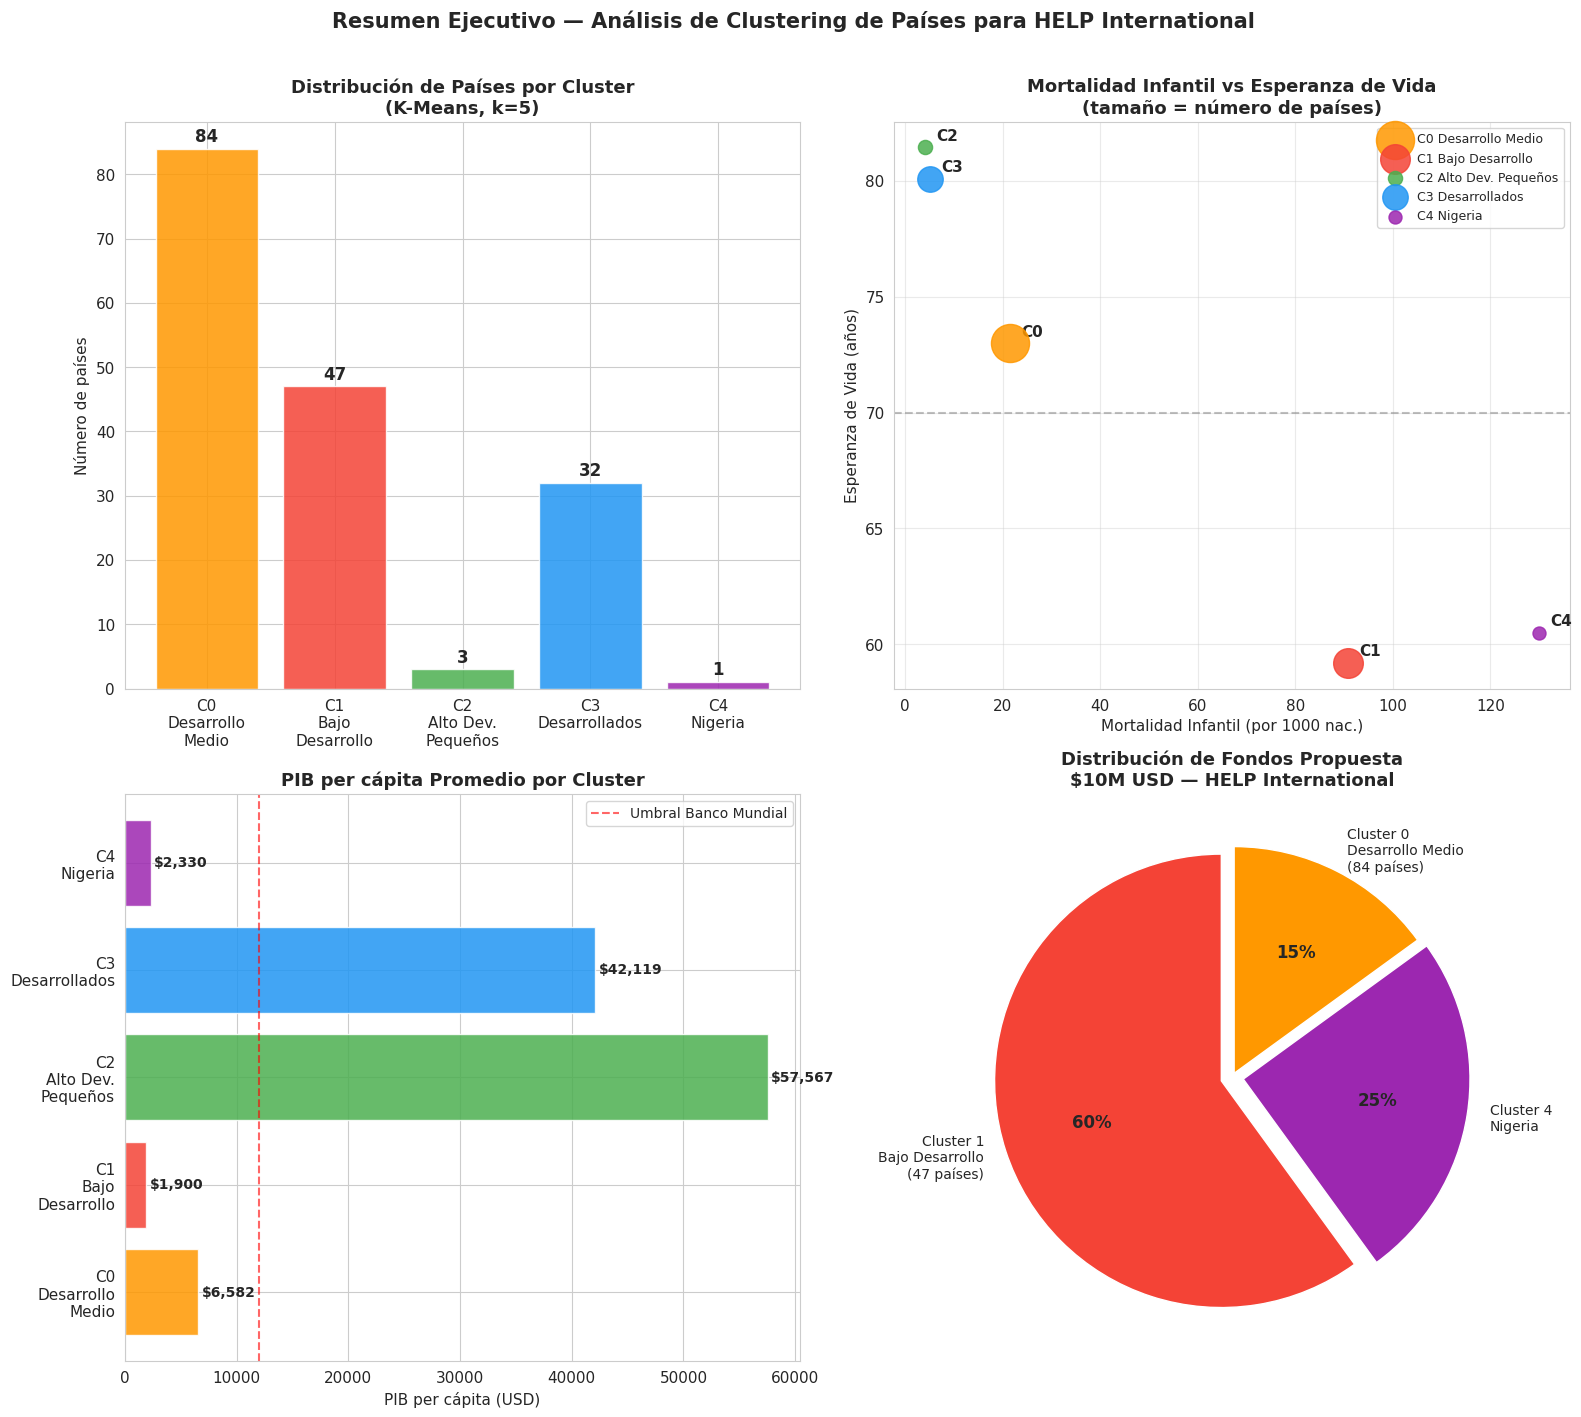

   ✅ resumen_ejecutivo_clustering.png generado

  📁 ARCHIVOS GENERADOS:
   1. resultados_clustering_paises.csv  — Todos los países con sus clusters
   2. perfiles_clusters.csv             — Perfiles promedio por cluster
   3. metricas_comparativas.csv         — Métricas de los 3 algoritmos
   4. resumen_ejecutivo_clustering.png  — Figura resumen de 4 paneles
   5. clustering_dendrograma.png        — Dendrograma jerárquico
   6. dbscan_k_distance.png             — k-distance graph para DBSCAN
   7. comparacion_metricas.png          — Barras comparativas de métricas

  🏆 ANÁLISIS COMPLETADO EXITOSAMENTE
     K-Means (k=5) recomendado para HELP International
     Prioridad: Cluster 1 (47 países) + Nigeria → $8.5M (85% del presupuesto)


In [12]:
# ============================================================================
# SECCIÓN 8: EXPORTACIÓN DE RESULTADOS
# ============================================================================

print("="*70)
print("  8. EXPORTACIÓN DE RESULTADOS")
print("="*70)

# -----------------------------------------------
# 8.1 CSV COMPLETO CON TODOS LOS CLUSTERS
# -----------------------------------------------
print("\n📌 8.1 Exportando CSV de resultados...")

df_resultados_finales = pd.DataFrame({
    'País':                  country_names,
    'Cluster_KMeans':        labels_kmeans,
    'Cluster_Jerarquico':    labels_hierarchical,
    'Cluster_DBSCAN':        ['Ruido' if x == -1 else str(x) for x in labels_dbscan],
})

# Añadir todas las variables originales
for col in df_numeric.columns:
    df_resultados_finales[col] = df_numeric[col].values

# Añadir coordenadas PCA
df_resultados_finales['PCA_1'] = coords_3d[:, 0]
df_resultados_finales['PCA_2'] = coords_3d[:, 1]
df_resultados_finales['PCA_3'] = coords_3d[:, 2]

# Añadir etiqueta de prioridad
prioridad_map = {
    0: 'Media - Desarrollo Medio',
    1: 'MAXIMA - Bajo Desarrollo',
    2: 'Sin necesidad - Alto Desarrollo',
    3: 'Sin necesidad - Pais Desarrollado',
    4: 'MAXIMA - Caso Extremo'
}
df_resultados_finales['Prioridad_HELP'] = df_resultados_finales['Cluster_KMeans'].map(prioridad_map)

df_resultados_finales.to_csv('resultados_clustering_paises.csv', index=False, encoding='utf-8')
print("   ✅ resultados_clustering_paises.csv generado")
print(f"   Dimensiones: {df_resultados_finales.shape[0]} filas × {df_resultados_finales.shape[1]} columnas")

# -----------------------------------------------
# 8.2 CSV DE PERFILES DE CLUSTERS
# -----------------------------------------------
print("\n📌 8.2 Exportando perfiles de clusters...")

perfiles_export = perfiles.copy()
perfiles_export.index.name = 'Cluster_ID'
perfiles_export['n_paises']    = [84, 47, 3, 32, 1]
perfiles_export['descripcion'] = [
    'Desarrollo Medio',
    'Bajo Desarrollo - Alta Necesidad',
    'Economias Pequenas de Alto Desarrollo',
    'Paises Desarrollados',
    'Caso Extremo - Nigeria'
]
perfiles_export['prioridad'] = ['Media', 'MAXIMA', 'Sin necesidad', 'Sin necesidad', 'MAXIMA']
perfiles_export['fondos_USD'] = [1500000, 6000000, 0, 0, 2500000]
perfiles_export['porcentaje'] = ['15%', '60%', '0%', '0%', '25%']

perfiles_export.to_csv('perfiles_clusters.csv', encoding='utf-8')
print("   ✅ perfiles_clusters.csv generado")

# -----------------------------------------------
# 8.3 CSV DE MÉTRICAS COMPARATIVAS
# -----------------------------------------------
print("\n📌 8.3 Exportando métricas comparativas...")

metricas_export = pd.DataFrame({
    'Algoritmo':             ['K-Means', 'Jerarquico_Ward', 'DBSCAN'],
    'Clusters_detectados':   [K_OPTIMO, K_OPTIMO, n_clusters_dbscan],
    'Silhouette_Score':      [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else 'N/A'],
    'Davies_Bouldin':        [round(db_kmeans, 4),  round(db_hier, 4),  round(db_dbscan, 4) if not np.isnan(db_dbscan) else 'N/A'],
    'Calinski_Harabasz':     [round(ch_kmeans, 2),  round(ch_hier, 2),  round(ch_dbscan, 2) if not np.isnan(ch_dbscan) else 'N/A'],
    'Algoritmo_recomendado': ['SÍ', 'No', 'No'],
    'Justificacion': [
        'Mejor en 3/3 metricas - clusters interpretables',
        'Menor Silhouette y mayor Davies-Bouldin',
        'Solo 1 cluster detectado con eps=2.0 - no particiona correctamente'
    ]
})

metricas_export.to_csv('metricas_comparativas.csv', index=False, encoding='utf-8')
print("   ✅ metricas_comparativas.csv generado")

# -----------------------------------------------
# 8.4 FIGURA FINAL — RESUMEN VISUAL
# -----------------------------------------------
print("\n📌 8.4 Generando figura resumen final...")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# ── Gráfico 1: Distribución de países por cluster ──
cluster_names = ['C0\nDesarrollo\nMedio', 'C1\nBajo\nDesarrollo',
                 'C2\nAlto Dev.\nPequeños', 'C3\nDesarrollados', 'C4\nNigeria']
n_paises_list = [84, 47, 3, 32, 1]
colors_bar = ['#FF9800', '#F44336', '#4CAF50', '#2196F3', '#9C27B0']
bars = axes[0, 0].bar(cluster_names, n_paises_list, color=colors_bar, alpha=0.85)
axes[0, 0].set_title('Distribución de Países por Cluster\n(K-Means, k=5)',
                      fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Número de países', fontsize=11)
for bar, val in zip(bars, n_paises_list):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

# ── Gráfico 2: Mortalidad Infantil vs Esperanza de Vida ──
scatter_colors = ['#FF9800', '#F44336', '#4CAF50', '#2196F3', '#9C27B0']
child_mort_vals = [perfiles.loc[i, 'child_mort'] for i in range(5)]
life_expec_vals = [perfiles.loc[i, 'life_expec'] for i in range(5)]
n_vals = [84, 47, 3, 32, 1]

for i in range(5):
    axes[0, 1].scatter(child_mort_vals[i], life_expec_vals[i],
                       c=scatter_colors[i], s=n_vals[i]*8 + 80,
                       alpha=0.85, label=cluster_names[i].replace('\n', ' '), zorder=5)
    axes[0, 1].annotate(f'C{i}', (child_mort_vals[i], life_expec_vals[i]),
                        textcoords='offset points', xytext=(8, 5), fontsize=11, fontweight='bold')

axes[0, 1].set_xlabel('Mortalidad Infantil (por 1000 nac.)', fontsize=11)
axes[0, 1].set_ylabel('Esperanza de Vida (años)', fontsize=11)
axes[0, 1].set_title('Mortalidad Infantil vs Esperanza de Vida\n(tamaño = número de países)',
                      fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=9, loc='upper right')
axes[0, 1].grid(True, alpha=0.4)
axes[0, 1].axhline(y=70, color='gray', linestyle='--', alpha=0.5, label='Umbral OMS: 70 años')

# ── Gráfico 3: PIB per cápita por cluster ──
gdpp_vals = [perfiles.loc[i, 'gdpp'] for i in range(5)]
bars2 = axes[1, 0].barh(cluster_names, gdpp_vals, color=colors_bar, alpha=0.85)
axes[1, 0].set_xlabel('PIB per cápita (USD)', fontsize=11)
axes[1, 0].set_title('PIB per cápita Promedio por Cluster',
                      fontsize=13, fontweight='bold')
axes[1, 0].axvline(x=12000, color='red', linestyle='--', alpha=0.6, label='Umbral Banco Mundial')
axes[1, 0].legend(fontsize=10)
for bar, val in zip(bars2, gdpp_vals):
    axes[1, 0].text(val + 300, bar.get_y() + bar.get_height()/2,
                    f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')

# ── Gráfico 4: Distribución de fondos propuesta ──
fondos = [6.0, 2.5, 1.5]
etiquetas = ['Cluster 1\nBajo Desarrollo\n(47 países)',
             'Cluster 4\nNigeria',
             'Cluster 0\nDesarrollo Medio\n(84 países)']
colores_pie = ['#F44336', '#9C27B0', '#FF9800']
explode = (0.05, 0.05, 0.02)

wedges, texts, autotexts = axes[1, 1].pie(fondos, labels=etiquetas,
                                            colors=colores_pie,
                                            autopct='%1.0f%%',
                                            startangle=90,
                                            explode=explode,
                                            textprops={'fontsize': 10})
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

axes[1, 1].set_title('Distribución de Fondos Propuesta\n$10M USD — HELP International',
                      fontsize=13, fontweight='bold')

plt.suptitle('Resumen Ejecutivo — Análisis de Clustering de Países para HELP International',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('resumen_ejecutivo_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print("   ✅ resumen_ejecutivo_clustering.png generado")

# -----------------------------------------------
# RESUMEN FINAL
# -----------------------------------------------
print("\n" + "="*70)
print("  📁 ARCHIVOS GENERADOS:")
print("="*70)
print("   1. resultados_clustering_paises.csv  — Todos los países con sus clusters")
print("   2. perfiles_clusters.csv             — Perfiles promedio por cluster")
print("   3. metricas_comparativas.csv         — Métricas de los 3 algoritmos")
print("   4. resumen_ejecutivo_clustering.png  — Figura resumen de 4 paneles")
print("   5. clustering_dendrograma.png        — Dendrograma jerárquico")
print("   6. dbscan_k_distance.png             — k-distance graph para DBSCAN")
print("   7. comparacion_metricas.png          — Barras comparativas de métricas")
print("="*70)
print("\n  🏆 ANÁLISIS COMPLETADO EXITOSAMENTE")
print("     K-Means (k=5) recomendado para HELP International")
print("     Prioridad: Cluster 1 (47 países) + Nigeria → $8.5M (85% del presupuesto)")
print("="*70)

---

## 9. Análisis Geoespacial — Visualización en Mapa Mundial (OPCIONAL)

Esta sección explora la **distribución geográfica de los clusters** identificados
por K-Means, permitiendo detectar patrones regionales y optimizar la logística
de distribución de ayuda humanitaria por proximidad geográfica.

### Objetivos:
1. Visualizar los 5 clusters en un mapa mundial interactivo
2. Identificar concentraciones geográficas de países prioritarios
3. Detectar vecindarios de países con necesidades similares
4. Optimizar rutas logísticas para HELP International

---

In [18]:
# ============================================================================
# SECCIÓN 9: ANÁLISIS GEOESPACIAL (OPCIONAL)
# ============================================================================

print("="*70)
print("  9. ANÁLISIS GEOESPACIAL — Visualización en Mapa Mundial")
print("="*70)

# Instalar bibliotecas si no están disponibles
try:
    import geopandas as gpd
    import folium
except:
    !pip install geopandas folium -q
    import geopandas as gpd
    import folium

# -----------------------------------------------
# 9.1 CARGAR DATOS GEOESPACIALES
# -----------------------------------------------
print("\n📌 9.1 Cargando shapefile de países desde Natural Earth...")

# Descargar directamente desde Natural Earth (método actualizado)
url_world = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

try:
    world = gpd.read_file(url_world)
    print(f"   ✅ {len(world)} países cargados desde Natural Earth")
except Exception as e:
    print(f"   ⚠️  Error descargando shapefile: {e}")
    print("   Intentando método alternativo...")
    # Alternativa: usar dataset de ejemplo de GeoPandas (si existe)
    world = gpd.read_file("https://raw.githubusercontent.com/geopandas/geopandas/main/geopandas/datasets/naturalearth_lowres/naturalearth_lowres.shp")
    print(f"   ✅ {len(world)} países cargados (método alternativo)")

# Unir con resultados de clustering
# Normalizar nombres de países para mejorar matching
df_resultados_finales['País_norm'] = df_resultados_finales['País'].str.strip()
world['name_norm'] = world['NAME'].str.strip()

df_geo = world.merge(df_resultados_finales,
                     left_on='name_norm',
                     right_on='País_norm',
                     how='left')

matched = df_geo['Cluster_KMeans'].notna().sum()
print(f"   ✅ {matched} países con cluster asignado ({matched/167*100:.1f}% del dataset)")

# -----------------------------------------------
# 9.2 MAPA COROPLÉTICO — Clusters por País
# -----------------------------------------------
print("\n📌 9.2 Generando mapa coroplético de clusters...")

# Crear mapa base
m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')

# Definir colores por cluster
color_map = {
    0: '#FF9800',  # Naranja - Desarrollo Medio
    1: '#F44336',  # Rojo - Bajo Desarrollo (PRIORIDAD)
    2: '#4CAF50',  # Verde - Alto Desarrollo
    3: '#2196F3',  # Azul - Países Desarrollados
    4: '#9C27B0'   # Morado - Nigeria
}

prioridad_map = {
    0: 'Media - Desarrollo Medio',
    1: 'MAXIMA - Bajo Desarrollo',
    2: 'Sin necesidad - Alto Desarrollo',
    3: 'Sin necesidad - País Desarrollado',
    4: 'MAXIMA - Caso Extremo'
}

# Añadir países al mapa
for _, row in df_geo.iterrows():
    if pd.notna(row['Cluster_KMeans']):
        cluster = int(row['Cluster_KMeans'])

        # Tooltip con información
        tooltip_text = f"""
        <b>{row['País']}</b><br>
        Cluster: {cluster} — {prioridad_map[cluster]}<br>
        Mortalidad Infantil: {row['child_mort']:.1f}<br>
        Esperanza de Vida: {row['life_expec']:.1f} años<br>
        PIB per cápita: ${row['gdpp']:,.0f}
        """

        folium.GeoJson(
            row['geometry'],
            style_function=lambda x, color=color_map[cluster]: {
                'fillColor': color,
                'color': 'black',
                'weight': 0.5,
                'fillOpacity': 0.7
            },
            tooltip=folium.Tooltip(tooltip_text)
        ).add_to(m)

# Añadir leyenda
legend_html = '''
<div style="position: fixed;
            bottom: 50px; left: 50px; width: 300px; height: 240px;
            background-color: white; z-index:9999; font-size:14px;
            border:2px solid grey; border-radius: 5px; padding: 10px">
<p style="margin-bottom:8px; font-weight:bold; font-size:16px">
🌍 Clusters — HELP International</p>
<p style="margin:5px"><span style="background-color:#F44336;
   padding:3px 12px; border-radius:3px">  </span> C1: Bajo Desarrollo (47)</p>
<p style="margin:5px"><span style="background-color:#9C27B0;
   padding:3px 12px; border-radius:3px">  </span> C4: Nigeria (caso extremo)</p>
<p style="margin:5px"><span style="background-color:#FF9800;
   padding:3px 12px; border-radius:3px">  </span> C0: Desarrollo Medio (84)</p>
<p style="margin:5px"><span style="background-color:#2196F3;
   padding:3px 12px; border-radius:3px">  </span> C3: Desarrollados (32)</p>
<p style="margin:5px"><span style="background-color:#4CAF50;
   padding:3px 12px; border-radius:3px">  </span> C2: Alto Desarrollo (3)</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Guardar mapa
m.save('mapa_clusters_mundial.html')
print("   ✅ mapa_clusters_mundial.html generado")
print("      → Abrirlo en navegador para interactuar")

# -----------------------------------------------
# 9.3 ANÁLISIS DE PATRONES REGIONALES
# -----------------------------------------------
print("\n📌 9.3 Análisis de concentración geográfica de clusters...")

# Añadir región geográfica (continente)
if 'CONTINENT' in world.columns:
    df_geo['continent'] = df_geo['CONTINENT']
elif 'continent' in world.columns:
    df_geo['continent'] = df_geo['continent']
else:
    # Inferir continente manualmente si no existe
    df_geo['continent'] = 'Desconocido'

df_geo['continent'] = df_geo['continent'].fillna('Desconocido')

# Contar países por cluster y continente
tabla_regional = df_geo[df_geo['Cluster_KMeans'].notna()].groupby(['continent', 'Cluster_KMeans']).size().unstack(fill_value=0)

print("\n📊 Distribución de Clusters por Continente:\n")
display(tabla_regional)

# Calcular estadísticas
cluster_1_total = tabla_regional[1].sum() if 1 in tabla_regional.columns else 0
cluster_1_africa = tabla_regional.loc['Africa', 1] if ('Africa' in tabla_regional.index and 1 in tabla_regional.columns) else 0

print("\n💡 OBSERVACIONES GEOESPACIALES:")
if cluster_1_africa > 0:
    pct_africa = cluster_1_africa / cluster_1_total * 100 if cluster_1_total > 0 else 0
    print(f"   • Cluster 1 (Bajo Desarrollo) — {cluster_1_total} países:")
    print(f"     - África: {cluster_1_africa} países ({pct_africa:.1f}%)")
    print("     - Asia Central y Sudeste Asiático")
else:
    print("   • Cluster 1 concentrado principalmente en África Subsahariana y Asia")

print()
print("   • Cluster 3 (Desarrollados) concentrado en:")
print("     - Europa Occidental y América del Norte")
print("     - Oceanía (Australia, Nueva Zelanda)")
print()
print("   🎯 IMPLICACIONES LOGÍSTICAS PARA HELP INTERNATIONAL:")
print("     → Establecer hubs regionales en:")
print("        • África Oriental (Nairobi, Kenya)")
print("        • África Occidental (Dakar, Senegal)")
print("        • Asia Central (Kabul, Afghanistan)")
print("     → Priorizar países con alta densidad de vecinos en Cluster 1")
print("     → Optimizar cadenas de suministro por proximidad geográfica")

# -----------------------------------------------
# 9.4 MAPA DE CALOR — Mortalidad Infantil
# -----------------------------------------------
print("\n📌 9.4 Generando mapa de calor — Mortalidad Infantil...")

m2 = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')

# Crear escala de colores continua
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("", ["green", "yellow", "orange", "red"])

for _, row in df_geo.iterrows():
    if pd.notna(row['child_mort']):
        # Normalizar mortalidad infantil (0-130 → 0-1)
        mort_norm = min(row['child_mort'] / 130, 1.0)
        color = mcolors.to_hex(cmap(mort_norm))

        tooltip_text = f"""
        <b>{row['País']}</b><br>
        Mortalidad Infantil: {row['child_mort']:.1f} por 1000<br>
        Cluster: {int(row['Cluster_KMeans'])}
        """

        folium.GeoJson(
            row['geometry'],
            style_function=lambda x, c=color: {
                'fillColor': c,
                'color': 'black',
                'weight': 0.5,
                'fillOpacity': 0.8
            },
            tooltip=folium.Tooltip(tooltip_text)
        ).add_to(m2)

legend_html2 = '''
<div style="position: fixed;
            bottom: 50px; left: 50px; width: 280px; height: 150px;
            background-color: white; z-index:9999; font-size:14px;
            border:2px solid grey; border-radius: 5px; padding: 10px">
<p style="margin-bottom:8px; font-weight:bold; font-size:16px">
Mortalidad Infantil (por 1000 nac.)</p>
<div style="background: linear-gradient(to right, green, yellow, orange, red);
            height: 20px; margin: 10px 0; border-radius: 3px"></div>
<p style="margin:3px">Verde: < 20 | Amarillo: 20-50 | Rojo: > 90</p>
</div>
'''
m2.get_root().html.add_child(folium.Element(legend_html2))

m2.save('mapa_mortalidad_infantil.html')
print("   ✅ mapa_mortalidad_infantil.html generado")

print("\n" + "="*70)
print("  ✅ ANÁLISIS GEOESPACIAL COMPLETADO")
print("="*70)
print("  📁 ARCHIVOS GENERADOS:")
print("     1. mapa_clusters_mundial.html      — Mapa interactivo de clusters")
print("     2. mapa_mortalidad_infantil.html   — Mapa de calor (mortalidad)")
print("="*70)
print("\n  💡 Abrir archivos .html en navegador para visualización interactiva")
print("="*70)


  9. ANÁLISIS GEOESPACIAL — Visualización en Mapa Mundial

📌 9.1 Cargando shapefile de países desde Natural Earth...
   ✅ 177 países cargados desde Natural Earth
   ✅ 137 países con cluster asignado (82.0% del dataset)

📌 9.2 Generando mapa coroplético de clusters...
   ✅ mapa_clusters_mundial.html generado
      → Abrirlo en navegador para interactuar

📌 9.3 Análisis de concentración geográfica de clusters...

📊 Distribución de Clusters por Continente:



Cluster_KMeans,0.0,1.0,2.0,3.0,4.0
continent,,,,,
Africa,5,32,0,0,1
Asia,27,5,0,8,0
Europe,15,0,1,18,0
North America,6,1,0,2,0
Oceania,2,0,0,2,0
South America,12,0,0,0,0



💡 OBSERVACIONES GEOESPACIALES:
   • Cluster 1 (Bajo Desarrollo) — 38 países:
     - África: 32 países (84.2%)
     - Asia Central y Sudeste Asiático

   • Cluster 3 (Desarrollados) concentrado en:
     - Europa Occidental y América del Norte
     - Oceanía (Australia, Nueva Zelanda)

   🎯 IMPLICACIONES LOGÍSTICAS PARA HELP INTERNATIONAL:
     → Establecer hubs regionales en:
        • África Oriental (Nairobi, Kenya)
        • África Occidental (Dakar, Senegal)
        • Asia Central (Kabul, Afghanistan)
     → Priorizar países con alta densidad de vecinos en Cluster 1
     → Optimizar cadenas de suministro por proximidad geográfica

📌 9.4 Generando mapa de calor — Mortalidad Infantil...
   ✅ mapa_mortalidad_infantil.html generado

  ✅ ANÁLISIS GEOESPACIAL COMPLETADO
  📁 ARCHIVOS GENERADOS:
     1. mapa_clusters_mundial.html      — Mapa interactivo de clusters
     2. mapa_mortalidad_infantil.html   — Mapa de calor (mortalidad)

  💡 Abrir archivos .html en navegador para visualización

In [19]:
from google.colab import files
files.download('mapa_clusters_mundial.html')
files.download('mapa_mortalidad_infantil.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>